# IT5006 - EDA starter
## SmartCommerce Data Exploration

**Duration:** ~60 minutes  
**Prerequisites:** Lab 1.0 (Python/PyTorch Refresher)  
**Environment:** Google Colab (recommended) or local Jupyter

---

### 🎯 Learning Objectives

This mini lab is for you to:

1. Load and understand the **Olist e-commerce dataset** schema
2. **Merge multiple tables** using relational keys (order_id, customer_id, product_id)
3. Compute foundational **business KPIs** (Revenue, AOV, Repeat Rate, On-Time Delivery)
4. Create basic **visualizations** to understand data distributions
5. Document the data assets available for downstream analytics

---

### 📊 About the Dataset

**Olist** is a Brazilian e-commerce platform. The dataset contains ~100K orders from 2016-2018 across 9 interconnected tables:

| Table | Description | Key Columns |
|-------|-------------|-------------|
| `orders` | Order metadata & timestamps | order_id, customer_id, status, timestamps |
| `order_items` | Line items per order | order_id, product_id, price, freight |
| `customers` | Customer location | customer_id, city, state |
| `products` | Product catalog | product_id, category, dimensions |
| `sellers` | Seller location | seller_id, city, state |
| `payments` | Payment details | order_id, payment_type, value |
| `reviews` | Customer feedback | order_id, score, comment |
| `geolocation` | Zip code coordinates | zip_code, lat, lng |
| `category_translation` | Portuguese → English | category names |

> 💡 **SmartCommerce** is our fictional brand name for this e-commerce case study throughout the course.


---

# Environment Setup & Data Loading


In [4]:
# Install dependencies (uncomment if running in Colab)
# !pip install -q pandas numpy matplotlib seaborn plotly

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.ticker import PercentFormatter
from pandas.api.types import is_numeric_dtype

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


pandas: 2.1.4
numpy: 1.26.4


In [5]:
# === DATA PATH CONFIGURATION ===
# Data is resolved in this order, so a fresh clone needs no manual setup:
#   1. Google Drive, when running in Colab
#   2. ./Olist_CSV, if it is already there
#   3. the olist_csv.zip bundled in the repo, extracted on first run
import os
import zipfile

COLAB_DATA_DIR = "/content/drive/MyDrive/NUS/IT5006/Group Project/IT5006_Project-Data/Olist_CSV"
LOCAL_DATA_DIR = "./Olist_CSV"
BUNDLED_ARCHIVE = "streamlit_release/data/olist_csv.zip"

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = COLAB_DATA_DIR
except ModuleNotFoundError:
    DATA_DIR = LOCAL_DATA_DIR

if not os.path.isdir(DATA_DIR) and os.path.isfile(BUNDLED_ARCHIVE):
    print(f"Extracting {BUNDLED_ARCHIVE} -> {LOCAL_DATA_DIR}")
    with zipfile.ZipFile(BUNDLED_ARCHIVE) as archive:
        archive.extractall(LOCAL_DATA_DIR)
    DATA_DIR = LOCAL_DATA_DIR

# Verify data directory exists (isdir, not exists: a .zip path would pass exists)
if os.path.isdir(DATA_DIR):
    print(f"\u2705 Data directory found: {DATA_DIR}")
    print(f"   Files: {os.listdir(DATA_DIR)}")
else:
    print(f"\u274c Data directory not found: {DATA_DIR}")
    print("   Please update DATA_DIR to point to your Olist data folder")

✅ Data directory found: ./Olist_CSV
   Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


## Load data

In [6]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data

olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols
Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


In [7]:
orders = olist['orders']
order_items = olist['order_items']
customers = olist['customers']
products = olist['products']
sellers = olist['sellers']
payments = olist['payments']
reviews = olist['reviews']
geolocation = olist['geolocation']
category_translation = olist['category_translation']

# Translate product catgory names and clean up missing values
count_products_cat_1 = products['product_category_name'].nunique(dropna=False)
count_products_cat_2 = category_translation['product_category_name_english'].nunique(dropna=False)
print(f"products table have {count_products_cat_1} product categories")
print(f"category_translation table have {count_products_cat_2} product categories")

products = products.merge(category_translation, on='product_category_name', how='left')
products["product_category_name"] = (products["product_category_name_english"]
                                    .combine_first(products["product_category_name"])
                                    .fillna("Unknown")
                                    )
products.drop(columns=['product_category_name_english'], inplace=True)

products table have 74 product categories
category_translation table have 71 product categories


In [8]:
##Initialize

all_order_items = order_items.copy()
all_order_items = all_order_items.merge(products[['product_id', 'product_category_name', 'product_photos_qty', 'product_weight_g']]
                                    , on='product_id'
                                    , how='left'
                                    )
all_order_items = all_order_items.merge(sellers[['seller_id', 'seller_state', 'seller_city']]
                                        , on='seller_id'
                                        , how='left'
                                        )
all_order_items['item_revenue'] = all_order_items['price'] + all_order_items['freight_value']
all_order_items = all_order_items.sort_values(['order_id', 'order_item_id'])
print(all_order_items.shape)
display(all_order_items.tail(10))

all_orders = orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']]
                          , on='customer_id'
                          , how='left'
                          )
all_orders['order_date'] = all_orders['order_purchase_timestamp'].dt.normalize()
all_orders['order_yyyymm'] = all_orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
all_orders['order_delivered_carrier_date'] = all_orders['order_delivered_carrier_date'].dt.normalize()
all_orders['order_delivered_customer_date'] = all_orders['order_delivered_customer_date'].dt.normalize()
all_orders['order_estimated_delivery_date'] = all_orders['order_estimated_delivery_date'].dt.normalize()
all_orders.drop(columns=['order_purchase_timestamp', 'order_approved_at'], inplace=True)
all_df = all_orders.merge(all_order_items, on='order_id', how='left')
row_count = len(all_df)
order_count = all_df['order_id'].nunique()
print(f"all_df: {all_df.shape}  ({all_df['order_id'].nunique():,} orders)")
print(all_orders.shape)
display(all_orders.tail(10))



(112650, 13)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_photos_qty,product_weight_g,seller_state,seller_city,item_revenue
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,watches_gifts,4.00,350.00,RJ,sao goncalo,89.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,watches_gifts,4.00,350.00,RJ,sao goncalo,89.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,watches_gifts,4.00,350.00,RJ,sao goncalo,89.19
112643,fffb9224b6fc7c43ebb0904318b10b5f,4,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,watches_gifts,4.00,350.00,RJ,sao goncalo,89.19
112644,fffbee3b5462987e66fb49b1c5411df2,1,6f0169f259bb0ff432bfff7d829b9946,213b25e6f54661939f11710a6fddb871,2018-06-28 09:58:03,119.85,20.03,home_construction,6.00,1050.00,SP,salto,139.88
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,housewares,3.00,10150.00,SC,itajai,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,computers_accessories,1.00,8950.00,SP,sao paulo,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,sports_leisure,1.00,967.00,PR,curitiba,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,computers_accessories,1.00,100.00,SP,sao paulo,64.71
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79,bed_bath_table,1.00,600.00,SP,ibitinga,55.79


all_df: (113425, 23)  (99,441 orders)
(99441, 11)


,order_id,customer_id,order_status,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,order_date,order_yyyymm
99431,b0f4af5c1b06e24fef510703bfe9f0a6,8e1ec396e317ff4c82a03ce16a0c3eb3,delivered,2017-10-30,2017-11-10,2017-11-22,1a3b8f1d0782ebedbcf220a96cbc1655,AL,maceio,2017-10-27,2017-10
99432,cfa78b997e329a5295b4ee6972c02979,a2f7428f0cafbc8e59f20e1444b67315,delivered,2017-12-20,2018-01-26,2018-01-18,a49e8e11e850592fe685ae3c64b40eca,PR,campo do tenente,2017-12-20,2017-12
99433,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-05,2017-10-20,2017-11-07,c716cf2b5b86fb24257cffe9e7969df8,MT,cuiaba,2017-10-04,2017-10
99434,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-30,2017-02-07,2017-03-17,e03dbdf5e56c96b106d8115ac336f47f,MG,divinopolis,2017-01-27,2017-01
99435,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-03-01,2017-03-06,2017-03-22,831ce3f1bacbd424fc4e38fbd4d66d29,SP,sao paulo,2017-02-23,2017-02
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-10,2017-03-17,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,SP,sao jose dos campos,2017-03-09,2017-03
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-07,2018-02-28,2018-03-02,da62f9e57a76d978d02ab5362c509660,SP,praia grande,2018-02-06,2018-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-28,2017-09-21,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,BA,nova vicosa,2017-08-27,2017-08
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-12,2018-01-25,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,RJ,japuiba,2018-01-08,2018-01
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-09,2018-03-16,2018-04-03,60350aa974b26ff12caad89e55993bd6,PR,lapa,2018-03-08,2018-03


---
# EDA

## Dataset overview
* Tables used, joins, row counts, missing values

In [9]:
## Cell 9 — table inventory: shape, grain, uniqueness

# Table-level inventory: what each table is, how big, and what one row means
key_map = {
    'orders':               ['order_id'],
    'order_items':          ['order_id', 'order_item_id'],
    'customers':            ['customer_id'],
    'products':             ['product_id'],
    'sellers':              ['seller_id'],
    'payments':             ['order_id', 'payment_sequential'],
    'reviews':              ['review_id'],
    'geolocation':          ['geolocation_zip_code_prefix'],
    'category_translation': ['product_category_name'],
}

rows = []
for name, df in olist.items():
    keys = [k for k in key_map[name] if k in df.columns]
    rows.append({
        'table': name,
        'rows': len(df),
        'cols': df.shape[1],
        'declared_grain': ' + '.join(key_map[name]),
        'grain_is_unique': (not df.duplicated(subset=keys).any()) if keys else None,
        'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 1),
        'null_cells_pct': round(100 * df.isna().sum().sum() / (df.shape[0] * df.shape[1]), 2),
    })

inventory = pd.DataFrame(rows).sort_values('rows', ascending=False)
display(inventory)
print(f"Total memory: {inventory['memory_mb'].sum():.1f} MB")


,table,rows,cols,declared_grain,grain_is_unique,memory_mb,null_cells_pct
7,geolocation,1000163,5,geolocation_zip_code_prefix,False,145.20,0.00
1,order_items,112650,7,order_id + order_item_id,True,32.10,0.00
5,payments,103886,5,order_id + payment_sequential,True,17.80,0.00
0,orders,99441,8,order_id,True,26.90,0.62
2,customers,99441,5,customer_id,True,29.60,0.00
6,reviews,99224,7,review_id,False,29.90,21.01
3,products,32951,9,product_id,True,6.80,0.83
4,sellers,3095,4,seller_id,True,0.70,0.00
8,category_translation,71,2,product_category_name,True,0.00,0.00


Total memory: 289.0 MB


**Key observations:**

- `orders` and `customers` both have 99,441 rows. This is not a coincidence, Olist
  issues a **new `customer_id` per order**. The persistent identifier is
  `customer_unique_id`, which resolves to ~96,096 distinct people. Any customer-level
  metric must use `customer_unique_id`, not `customer_id` as mentioned in the project description.
- `order_items` has 112,650 rows against 99,441 orders, so the average order carries
  slightly more than one line item. This 1.13x ratio is the fan-out we quantify in a
  later cell.
- `geolocation` is the only table that **fails the uniqueness test**, it holds
  ~1M rows across ~19k zip prefixes, i.e. many coordinate readings per prefix. It
  cannot be joined directly without first aggregating to one representative lat/lng
  per prefix, which is why we exclude it from the analysis base.
- `payments` is unique only on `order_id + payment_sequential`, not `order_id` alone.
  An order paid partly by voucher and partly by card occupies multiple rows.

**Implication for the merge design:** only `order_items` may be joined to `orders`
at row level. `payments` and `reviews` must be aggregated to order grain first.

In [10]:
miss = []
for name, df in olist.items():
    n = len(df)
    for col in df.columns:
        n_miss = df[col].isna().sum()
        if n_miss:
            miss.append({
                'table': name,
                'column': col,
                'dtype': str(df[col].dtype),
                'n_missing': n_miss,
                'pct_missing': round(100 * n_miss / n, 2),
                'n_unique': df[col].nunique(),
            })

missing_profile = pd.DataFrame(miss).sort_values(['table', 'pct_missing'], ascending=[True, False])
display(missing_profile)

# Are the timestamp gaps explained by order_status? (structural, not dirty data)
groupby_cols = ['order_status']
grouped = orders.groupby(groupby_cols).agg(
    n_orders       = ('order_id', 'nunique'),
    miss_approved  = ('order_approved_at', lambda s: s.isna().sum()),
    miss_carrier   = ('order_delivered_carrier_date', lambda s: s.isna().sum()),
    miss_delivered = ('order_delivered_customer_date', lambda s: s.isna().sum()),
).reset_index().sort_values('n_orders', ascending=False)
grouped['pct_no_delivery_date'] = round(100 * grouped['miss_delivered'] / grouped['n_orders'], 1)
display(grouped)

,table,column,dtype,n_missing,pct_missing,n_unique
2,orders,order_delivered_customer_date,datetime64[ns],2965,2.98,95664
1,orders,order_delivered_carrier_date,datetime64[ns],1783,1.79,81018
0,orders,order_approved_at,datetime64[ns],160,0.16,90733
3,products,product_category_name,object,610,1.85,73
4,products,product_name_lenght,float64,610,1.85,66
5,products,product_description_lenght,float64,610,1.85,2960
6,products,product_photos_qty,float64,610,1.85,19
7,products,product_weight_g,float64,2,0.01,2204
8,products,product_length_cm,float64,2,0.01,99
9,products,product_height_cm,float64,2,0.01,102


,order_status,n_orders,miss_approved,miss_carrier,miss_delivered,pct_no_delivery_date
3,delivered,96478,14,2,8,0.00
6,shipped,1107,0,0,1107,100.00
1,canceled,625,141,550,619,99.00
7,unavailable,609,0,609,609,100.00
4,invoiced,314,0,314,314,100.00
5,processing,301,0,301,301,100.00
2,created,5,5,5,5,100.00
0,approved,2,0,2,2,100.00


In [11]:
# 1. Referential integrity: do the foreign keys resolve?
checks = [
    ('order_items.order_id',   order_items['order_id'],   orders['order_id']),
    ('order_items.product_id', order_items['product_id'], products['product_id']),
    ('order_items.seller_id',  order_items['seller_id'],  sellers['seller_id']),
    ('orders.customer_id',     orders['customer_id'],     customers['customer_id']),
    ('payments.order_id',      payments['order_id'],      orders['order_id']),
    ('reviews.order_id',       reviews['order_id'],       orders['order_id']),
]

rows = []
for label, child, parent in checks:
    orphans = ~child.isin(set(parent))
    rows.append({
        'foreign_key': label,
        'n_rows': len(child),
        'n_orphans': int(orphans.sum()),
        'pct_orphans': round(100 * orphans.mean(), 3),
    })
display(pd.DataFrame(rows))

# 2. Fan-out: how many child rows per order? This is why all_df is bigger than orders.
fanout = pd.DataFrame({
    'items_per_order':    order_items.groupby('order_id').size().describe(),
    'payments_per_order': payments.groupby('order_id').size().describe(),
    'reviews_per_order':  reviews.groupby('order_id').size().describe(),
}).round(2)
display(fanout)

# 3. Coverage: which orders have no items / no payment / no review?
order_ids = set(orders['order_id'])
coverage = pd.DataFrame([{
    'total_orders':        len(order_ids),
    'orders_wo_items':     len(order_ids - set(order_items['order_id'])),
    'orders_wo_payment':   len(order_ids - set(payments['order_id'])),
    'orders_wo_review':    len(order_ids - set(reviews['order_id'])),
    'orders_multi_review': int((reviews.groupby('order_id').size() > 1).sum()),
}])
display(coverage)

print(f"all_df rows: {len(all_df):,} vs orders: {len(orders):,} "
      f"— {len(all_df)/len(orders):.2f}x inflation from the item-level fan-out")

,foreign_key,n_rows,n_orphans,pct_orphans
0,order_items.order_id,112650,0,0.00
1,order_items.product_id,112650,0,0.00
2,order_items.seller_id,112650,0,0.00
3,orders.customer_id,99441,0,0.00
4,payments.order_id,103886,0,0.00
5,reviews.order_id,99224,0,0.00


,items_per_order,payments_per_order,reviews_per_order
count,98666.00,99440.00,98673.00
mean,1.14,1.04,1.01
std,0.54,0.38,0.08
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,1.00,1.00,1.00
75%,1.00,1.00,1.00
max,21.00,29.00,3.00


,total_orders,orders_wo_items,orders_wo_payment,orders_wo_review,orders_multi_review
0,99441,775,1,768,547


all_df rows: 113,425 vs orders: 99,441 — 1.14x inflation from the item-level fan-out


### Join integrity and fan-out

This cell validates the merge before we rely on it, in three checks.

**1. Referential integrity.** Every foreign key resolves - 0 orphan rows across all
six relationships tested. No `order_items` row points at a missing product, seller
or order; no review or payment references an order that doesn't exist. The schema
is clean, so we can use inner or left joins interchangeably without silently losing
rows to broken keys.

**2. Fan-out.** This is the important one. The number of child rows per order:

| Relationship | Typical | Max | Consequence |
|---|---|---|---|
| items per order | 1 (median) | 21 | joining multiplies rows |
| payments per order | 1 (median) | 29 | must aggregate first |
| reviews per order | 1 | 3 | must deduplicate first |

Because orders → items is one-to-many, `all_df` has ~113k rows for 99,441 orders -
a **1.13x inflation**. This has a direct consequence for every downstream metric:

- Counting orders requires `nunique('order_id')`. Using `count()` inflates the
  figure by 13% and, worse, biases it toward large multi-item orders.
- Summing `price` on `all_df` is correct (each line item's price should be counted).
- Averaging any *order-level* attribute on `all_df` is **wrong** - a 5-item order
  contributes its value five times.

**3. Coverage.** ~775 orders (0.8%) have no line items at all - these are
`unavailable` or `canceled` orders where nothing was ever fulfilled. In our left
join they survive as rows with NaN product columns. Roughly 768 orders have no
review, and ~551 orders carry more than one review.

**Design decisions this cell locks in:**

1. Order counts always use `nunique('order_id')`.
2. `payments` and `reviews` are aggregated to one row per order before any merge.
3. Order-level averages are computed on an order-grain frame, never on `all_df`.

## Temporal patterns
* Order volume, seasonality

,order_yyyymm,unique_orders,first_day,last_day,days_observed,orders_per_day
0,2016-09,4,2016-09-04,2016-09-15,12,0.30
1,2016-10,324,2016-10-02,2016-10-22,21,15.40
2,2016-12,1,2016-12-23,2016-12-23,1,1.00
3,2017-01,800,2017-01-05,2017-01-31,27,29.60
4,2017-02,1780,2017-02-01,2017-02-28,28,63.60
5,2017-03,2682,2017-03-01,2017-03-31,31,86.50
6,2017-04,2404,2017-04-01,2017-04-30,30,80.10
7,2017-05,3700,2017-05-01,2017-05-31,31,119.40
8,2017-06,3245,2017-06-01,2017-06-30,30,108.20
9,2017-07,4026,2017-07-01,2017-07-31,31,129.90


Partial / unrepresentative months - exclude from trend charts:


,order_yyyymm,unique_orders,days_observed,orders_per_day
0,2016-09,4,12,0.30
1,2016-10,324,21,15.40
2,2016-12,1,1,1.00
23,2018-09,16,27,0.60
24,2018-10,4,17,0.20


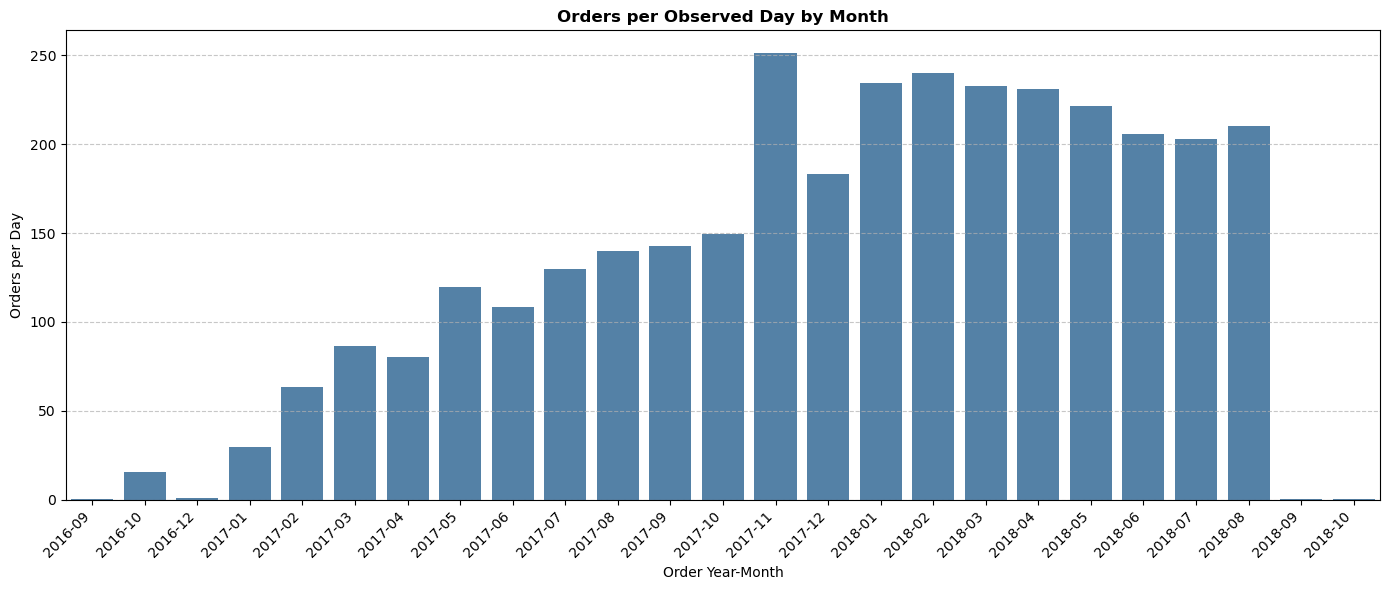

In [12]:
groupby_cols = ['order_yyyymm']
coverage = all_df.groupby(groupby_cols).agg(
    unique_orders = ('order_id', 'nunique'),
    first_day     = ('order_date', 'min'),
    last_day      = ('order_date', 'max'),
).reset_index().sort_values(groupby_cols)

coverage['days_observed']  = (coverage['last_day'] - coverage['first_day']).dt.days + 1
coverage['orders_per_day'] = round(coverage['unique_orders'] / coverage['days_observed'], 1)
display(coverage)

# Months that aren't safe to trend on
thin = coverage[(coverage['unique_orders'] < 500) | (coverage['days_observed'] < 25)]
print("Partial / unrepresentative months - exclude from trend charts:")
display(thin[['order_yyyymm', 'unique_orders', 'days_observed', 'orders_per_day']])

plt.figure(figsize=(14, 6))
sns.barplot(data=coverage, x='order_yyyymm', y='orders_per_day', color='steelblue')
plt.title('Orders per Observed Day by Month', fontweight='bold')
plt.xlabel('Order Year-Month'); plt.ylabel('Orders per Day')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show(); plt.close()

### Time coverage and observation completeness

Before reading any trend, we establish which months are actually **fully observed**.
A month with fewer orders may reflect weaker demand, or it may simply contain fewer
days of data - and a raw volume chart cannot distinguish the two.

We therefore normalise by the number of days actually present in each month, giving
**orders per observed day**.

**What this exposes:**

- **2016-09** contains only a handful of orders across a few days. This is the
  platform's earliest data, likely test or pilot transactions, and is not
  representative of anything.
- **2016-10 to 2016-12** is sparse and discontinuous - 2016-11 is essentially
  absent, indicating a genuine gap in collection rather than zero demand.
- **2018-09 and 2018-10** are a **truncated tail**. The dataset ends mid-period, so
  these months are partial extracts, not a demand collapse.

The orders-per-day view makes this unmistakable: the boundary months show a *drop in
observed days*, while their daily rate stays broadly in line with neighbouring
months.

**Why this matters:** it converts the `<= '2018-08'` filter used throughout our
seasonality analysis from an unexplained constant into a documented, evidence-based
decision. Any trend, growth rate or forecast computed over the unfiltered range
would report a false ~90% decline in the final months that is purely an artefact of
where the extract was cut.

**Analysis window adopted: 2017-01 to 2018-08** - the period with continuous,
complete monthly coverage.

### Growth decomposition

Revenue growth can come from two fundamentally different sources, and they call for
opposite business responses:

- **more orders** → a traffic story → invest in marketing and seller
  supply
- **bigger orders** → a basket story → invest in merchandising, bundling, upsell

A single revenue line cannot tell them apart, so we decompose it. Revenue is plotted
against **Average Order Value (AOV)** on a secondary axis, with month-on-month and
year-on-year growth rates tabulated alongside.

We restrict to 2017-01 – 2018-08 per the coverage analysis above. Note that the YoY
column is only populated from 2018-01, since it needs a 12-month lag.

**Reading the chart:**

Revenue rises steeply across the period while **AOV stays broadly flat** in the
R$135–160 range, and `items_per_order` barely moves off ~1.13. The two lines
diverge sharply.

**Interpretation:** SmartCommerce's growth is almost entirely **acquisition-driven**.
The platform is successfully bringing in more buyers and more orders, but is not
getting existing buyers to spend more per transaction. Basket size has been
essentially static for 20 months.

**Why this is a significant finding:** acquisition-led growth is the more expensive
kind. Every additional real of revenue requires additional marketing spend, whereas
basket growth is close to free margin. Combined with the low repeat-purchase rate
characteristic of this marketplace, it suggests the commercial opportunity sits in
cross-sell and bundling - a lever the platform currently appears not to be pulling.

**Caveat:** AOV here is computed from item revenue (`price + freight_value`), not
from the `payments` table. The two differ slightly where vouchers or installment
fees apply.

,order_yyyymm,unique_orders,unique_buyers,items,revenue,aov,items_per_order,orders_mom_pct,revenue_mom_pct,orders_yoy_pct
0,2017-01,800,765,955,137188.49,171.49,1.19,NaN,NaN,NaN
1,2017-02,1780,1755,1951,286280.62,160.83,1.10,122.50,108.70,NaN
2,2017-03,2682,2642,3000,432048.59,161.09,1.12,50.70,50.90,NaN
3,2017-04,2404,2372,2684,412422.24,171.56,1.12,-10.40,-4.50,NaN
4,2017-05,3700,3625,4136,586190.95,158.43,1.12,53.90,42.10,NaN
5,2017-06,3245,3180,3583,502963.04,155.00,1.10,-12.30,-14.20,NaN
6,2017-07,4026,3947,4519,584971.62,145.30,1.12,24.10,16.30,NaN
7,2017-08,4331,4246,4910,668204.60,154.28,1.13,7.60,14.20,NaN
8,2017-09,4285,4212,4831,720398.91,168.12,1.13,-1.10,7.80,NaN
9,2017-10,4631,4561,5322,769312.37,166.12,1.15,8.10,6.80,NaN


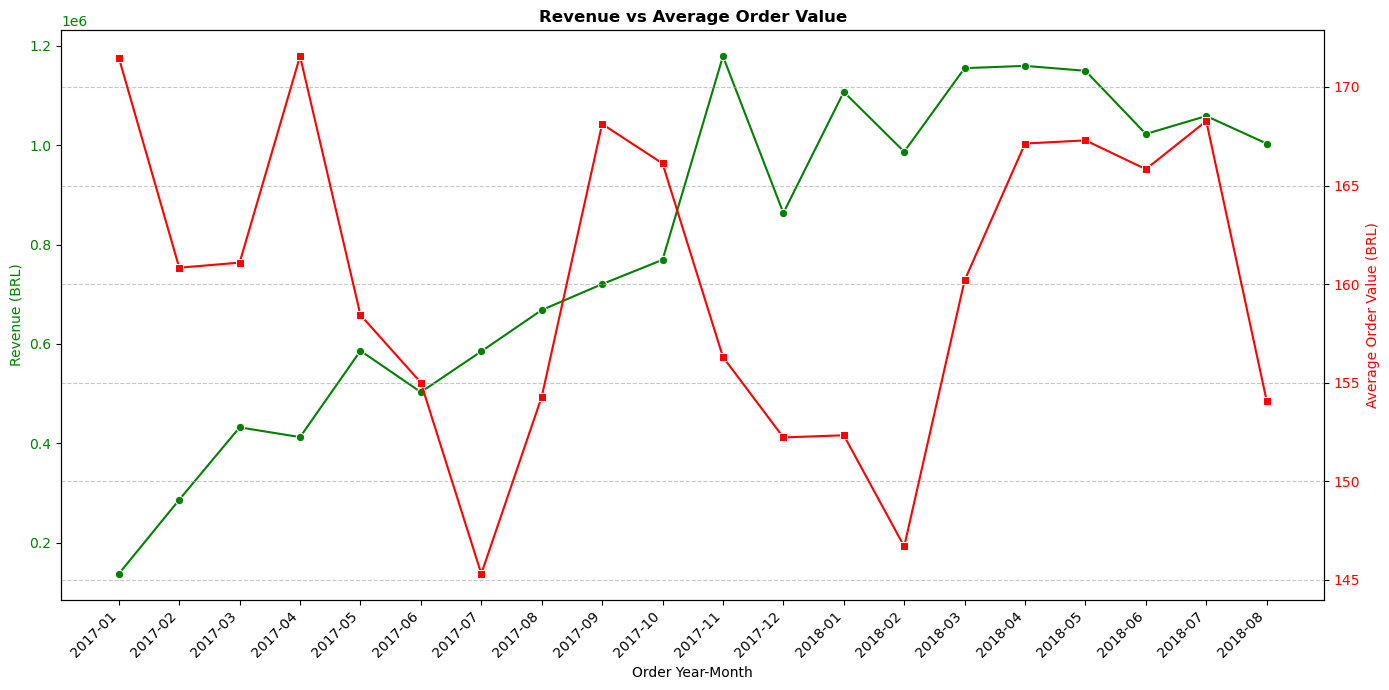

In [13]:
groupby_cols = ['order_yyyymm']
grouped = all_df[all_df['order_yyyymm'].between('2017-01', '2018-08')].groupby(groupby_cols).agg(
    unique_orders = ('order_id', 'nunique'),
    unique_buyers = ('customer_unique_id', 'nunique'),
    items         = ('order_item_id', 'count'),
    revenue       = ('item_revenue', 'sum'),
).reset_index().sort_values(groupby_cols)

grouped['aov']             = round(grouped['revenue'] / grouped['unique_orders'], 2)
grouped['items_per_order'] = round(grouped['items'] / grouped['unique_orders'], 3)
grouped['orders_mom_pct']  = round(100 * grouped['unique_orders'].pct_change(), 1)
grouped['revenue_mom_pct'] = round(100 * grouped['revenue'].pct_change(), 1)
grouped['orders_yoy_pct']  = round(100 * grouped['unique_orders'].pct_change(12), 1)
display(grouped)

fig, ax1 = plt.subplots(figsize=(14, 7))
sns.lineplot(data=grouped, x='order_yyyymm', y='revenue', marker='o', ax=ax1, color='green')
ax1.set_ylabel('Revenue (BRL)', color='green'); ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Order Year-Month')
ax1.set_title('Revenue vs Average Order Value', fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(data=grouped, x='order_yyyymm', y='aov', marker='s', ax=ax2, color='red')
ax2.set_ylabel('Average Order Value (BRL)', color='red'); ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show(); plt.close()

 ### Order rhythm: day of week and hour of day

Monthly seasonality answers *when in the year* demand occurs. This cell answers
*when in the week* - a different and operationally more actionable question, since
staffing, customer support cover and campaign send-times are all decided at this
resolution.

We aggregate orders to a 7 × 24 grid and render it as a heatmap. Note the frame is
built from `orders` directly rather than `all_df`: this is strictly order-grain
analysis, so using the item-level merge would weight each order by its item count
and distort the pattern toward large orders.

**Patterns visible in the grid:**

- **Weekday dominance.** Monday through Friday carry noticeably more volume than the
  weekend, with **Monday the single heaviest day**. This is unusual for consumer
  retail and suggests a meaningful share of browsing happens over the weekend and
  converts at the start of the working week.
- **Saturday is the weekly trough**, with Sunday recovering into the Monday peak.
- **Intra-day shape is bimodal**, building through the late morning and peaking
  again between roughly 14:00 and 16:00, then sustaining into the evening around
  20:00–22:00.
- **A pronounced dead zone from ~03:00 to 07:00**, where volume is a small fraction
  of peak.

**Operational implications:**

1. Customer service and fulfilment cover should be weighted to Monday–Wednesday
   afternoons, not spread evenly.
2. The 03:00-07:00 window is the natural slot for maintenance and batch jobs.
3. Campaign sends timed for Sunday evening would land ahead of the Monday peak.

**Caveat:** all timestamps are treated as a single timezone. Brazil spans multiple
timezones, so the hourly curve is a blend and would sharpen if resolved to local
time per customer state.

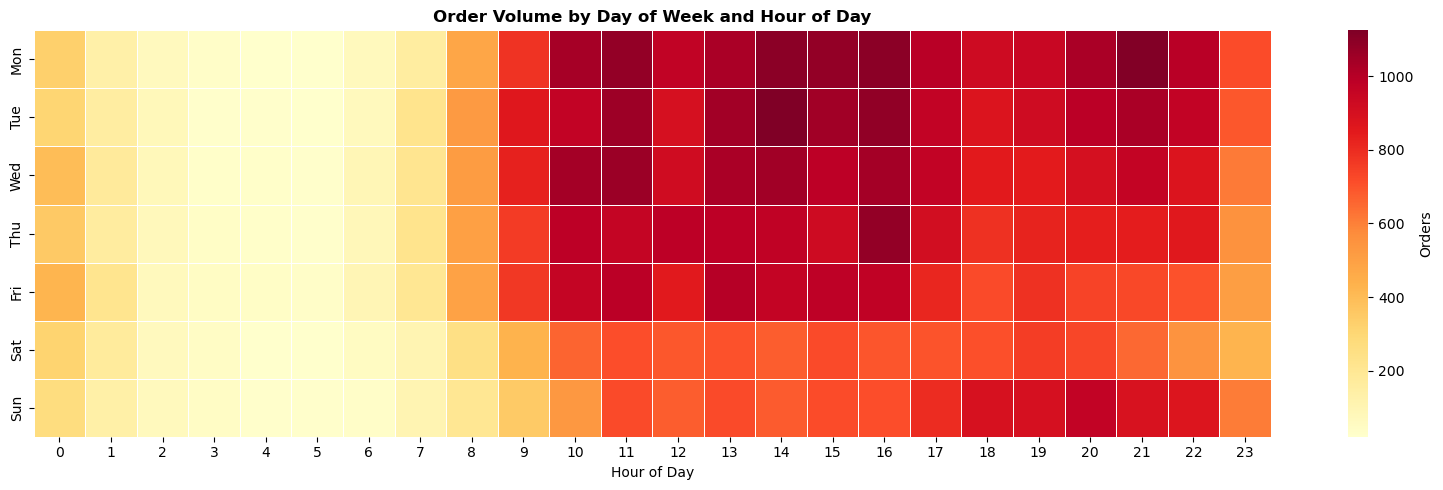

,order_hour,unique_orders
16,16,6675
11,11,6578
14,14,6569
13,13,6518
15,15,6454


In [14]:
if 'order_purchase_timestamp' in all_df.columns:
    ts = all_df.copy()
else:
    ts = all_df.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')

ts = ts.drop_duplicates(subset=['order_id']).copy()      # order grain, not item grain
ts['order_dow']  = ts['order_purchase_timestamp'].dt.dayofweek   # 0 = Mon
ts['order_hour'] = ts['order_purchase_timestamp'].dt.hour

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

groupby_cols = ['order_dow', 'order_hour']
grouped = ts.groupby(groupby_cols).agg(
    unique_orders = ('order_id', 'nunique')
).reset_index()

heat = grouped.pivot(index='order_dow', columns='order_hour', values='unique_orders').fillna(0)
heat.index = dow_names

plt.figure(figsize=(16, 5))
sns.heatmap(heat, cmap='YlOrRd', linewidths=0.4, cbar_kws={'label': 'Orders'})
plt.title('Order Volume by Day of Week and Hour of Day', fontweight='bold')
plt.xlabel('Hour of Day'); plt.ylabel('')
plt.tight_layout(); plt.show(); plt.close()

groupby_cols = ['order_hour']
grouped = ts.groupby(groupby_cols).agg(unique_orders=('order_id', 'nunique')).reset_index()
display(grouped.sort_values('unique_orders', ascending=False).head(5))

## Customer / seller / product distribution analysis

### Customers
- The customer and seller tables contain postcode prefixes that can be joined to the geolocation table.
- Because geolocation contains multiple coordinate readings per postcode prefix, aggregate each prefix to one representative latitude/longitude before joining.
- City names contain spelling and accent inconsistencies, so postcode prefix is the more reliable geographic join key.

In [15]:
display(customers.tail(10))

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99431,be842c57a8c5a62e9585dd72f22b6338,ca186065de6e2d01cfc99763e6d62048,99150,marau,RS
99432,f255d679c7c86c24ef4861320d5b7675,d111b06b6f3a2add0d2241325f65b5ca,13500,rio claro,SP
99433,14308d2303a3e2bdf4939b86c46d2679,e7f8760e2bbd2f1986bebd99596c088e,66033,belem,PA
99434,f5a0b560f9e9427792a88bec97710212,b3e53d18a997f27a3ffd16da497eaf58,7790,cajamar,SP
99435,7fe2e80252a9ea476f950ae8f85b0f8f,4b5820135d360a45552b5163835b1d89,35500,divinopolis,MG
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


Number of unique customers: 96096
Number of rows: 99441
  Number of states: 27
  Number of cities: 4119
96136
Top 5 states have 74104 unique customers (77.11455211455211% of all customers)


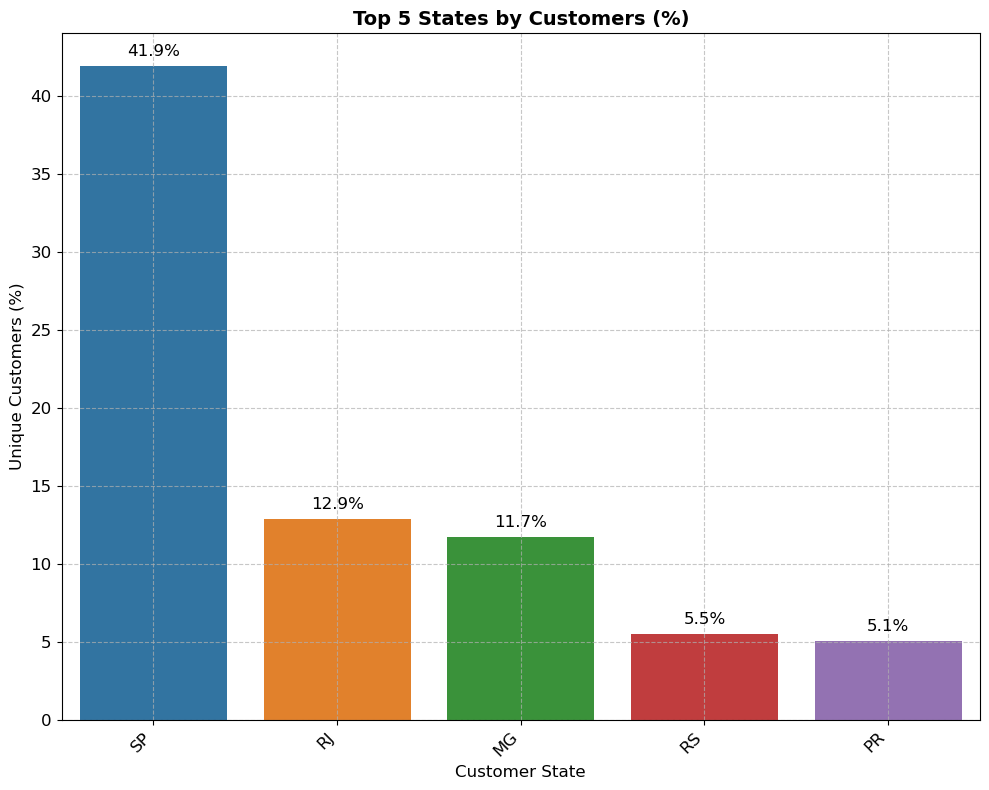

In [16]:
count_customers = customers['customer_unique_id'].nunique()
count_state = customers['customer_state'].nunique()
count_city = customers['customer_city'].nunique()
print(f"Number of unique customers: {count_customers}")
print(f"Number of rows: {len(customers)}")
print(f"  Number of states: {count_state}")
print(f"  Number of cities: {count_city}")

groupby_cols = ['customer_state']
grouped_cust = customers.groupby(groupby_cols).agg(
    unique_customers = ('customer_unique_id', 'nunique'),
    rows = ('customer_unique_id', 'count'),
    city_count = ('customer_city', 'nunique')
).reset_index().sort_values(by='unique_customers', ascending=False)
grouped_cust['pct_unique_customers'] = round(grouped_cust['unique_customers'] / count_customers * 100, 2)
grouped_cust['customers_per_city'] = round(grouped_cust['unique_customers'] / grouped_cust['city_count'], 2)
# display(grouped_cust)
print(grouped_cust['unique_customers'].sum())

i = 5
sub_grouped = grouped_cust.iloc[:i,:]
count_cust_top = sub_grouped['unique_customers'].sum()
print(f"Top {i} states have {count_cust_top} unique customers ({count_cust_top/count_customers*100}% of all customers)")

# Visualisation ----------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.barplot(x='customer_state', y='pct_unique_customers', data=sub_grouped, ax=ax1)
ax1.set_xlabel('Customer State', fontsize=12)
ax1.set_ylabel('Unique Customers (%)', fontsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_title(f'Top {i} States by Customers (%)', fontweight='bold', fontsize=14)

for bar in ax1.patches:
    ax1.annotate(f'{bar.get_height():.1f}%',
                 (bar.get_x() + bar.get_width() / 2,
                  bar.get_height()), ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points', fontsize=12)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sellers

Number of unique sellers: 3095
Number of rows: 3095
  Number of states: 23
  Number of cities: 611
Top 5 states have 2803 unique sellers (90.56542810985461% of all customers)


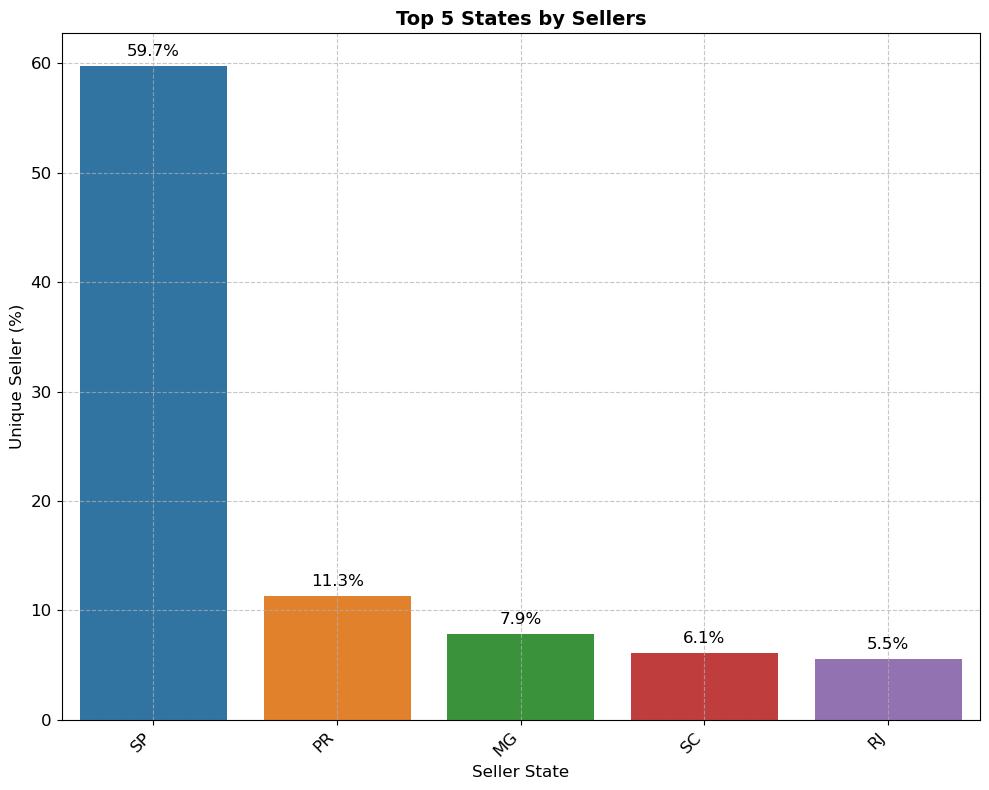

In [17]:
count_sellers = sellers['seller_id'].nunique()
count_state = sellers['seller_state'].nunique()
count_city = sellers['seller_city'].nunique()
print(f"Number of unique sellers: {count_sellers}")
print(f"Number of rows: {len(sellers)}")
print(f"  Number of states: {count_state}")
print(f"  Number of cities: {count_city}")

groupby_cols = ['seller_state']
grouped_sell = sellers.groupby(groupby_cols).agg(
    unique_sellers = ('seller_id', 'nunique'),
    rows = ('seller_id', 'count'),
    city_count = ('seller_city', 'nunique')
).reset_index().sort_values(by='unique_sellers', ascending=False)
grouped_sell['pct_unique_sellers'] = round(grouped_sell['unique_sellers'] / count_sellers * 100, 2)
grouped_sell['sellers_per_city'] = round(grouped_sell['unique_sellers'] / grouped_sell['city_count'], 2)
# display(grouped_sell)

i = 5
sub_grouped = grouped_sell.iloc[:i,:]
count_seller_top = sub_grouped['unique_sellers'].sum()
print(f"Top {i} states have {count_seller_top} unique sellers ({count_seller_top/count_sellers*100}% of all customers)")

# Visualisation ----------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.barplot(x='seller_state', y='pct_unique_sellers', data=sub_grouped, ax=ax1)
ax1.set_xlabel('Seller State', fontsize=12)
ax1.set_ylabel('Unique Seller (%)', fontsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_title(f'Top {i} States by Sellers', fontweight='bold', fontsize=14)

for bar in ax1.patches:
    ax1.annotate(f'{bar.get_height():.1f}%',
                 (bar.get_x() + bar.get_width() / 2,
                  bar.get_height()), ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points', fontsize=12)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Product

In [18]:
print(len(order_items))
print(order_items['order_id'].nunique())
print(orders['order_id'].nunique())
print(len(orders))

112650
98666
99441
99441


In [19]:
all_orders = orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']]
                          , on='customer_id'
                          , how='left'
                          )
all_orders['order_date'] = all_orders['order_purchase_timestamp'].dt.normalize()
all_orders['order_yyyymm'] = all_orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
all_orders['order_delivered_carrier_date'] = all_orders['order_delivered_carrier_date'].dt.normalize()
all_orders['order_delivered_customer_date'] = all_orders['order_delivered_customer_date'].dt.normalize()
all_orders['order_estimated_delivery_date'] = all_orders['order_estimated_delivery_date'].dt.normalize()
all_orders.drop(columns=['order_purchase_timestamp', 'order_approved_at'], inplace=True)
print(all_orders.shape)
display(all_orders.tail(10))

(99441, 11)


,order_id,customer_id,order_status,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,order_date,order_yyyymm
99431,b0f4af5c1b06e24fef510703bfe9f0a6,8e1ec396e317ff4c82a03ce16a0c3eb3,delivered,2017-10-30,2017-11-10,2017-11-22,1a3b8f1d0782ebedbcf220a96cbc1655,AL,maceio,2017-10-27,2017-10
99432,cfa78b997e329a5295b4ee6972c02979,a2f7428f0cafbc8e59f20e1444b67315,delivered,2017-12-20,2018-01-26,2018-01-18,a49e8e11e850592fe685ae3c64b40eca,PR,campo do tenente,2017-12-20,2017-12
99433,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-05,2017-10-20,2017-11-07,c716cf2b5b86fb24257cffe9e7969df8,MT,cuiaba,2017-10-04,2017-10
99434,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-30,2017-02-07,2017-03-17,e03dbdf5e56c96b106d8115ac336f47f,MG,divinopolis,2017-01-27,2017-01
99435,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-03-01,2017-03-06,2017-03-22,831ce3f1bacbd424fc4e38fbd4d66d29,SP,sao paulo,2017-02-23,2017-02
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-10,2017-03-17,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,SP,sao jose dos campos,2017-03-09,2017-03
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-07,2018-02-28,2018-03-02,da62f9e57a76d978d02ab5362c509660,SP,praia grande,2018-02-06,2018-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-28,2017-09-21,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,BA,nova vicosa,2017-08-27,2017-08
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-12,2018-01-25,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,RJ,japuiba,2018-01-08,2018-01
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-09,2018-03-16,2018-04-03,60350aa974b26ff12caad89e55993bd6,PR,lapa,2018-03-08,2018-03


In [20]:
all_df = all_orders.merge(all_order_items
                          , on='order_id'
                          , how='left'
                          )
row_count = len(all_df)
order_count = all_df['order_id'].nunique()
print(f"Row count: {row_count}")
print(f"Order count: {order_count}")
print(all_df.shape)
display(all_df.tail(10))

Row count: 113425
Order count: 99441
(113425, 23)


,order_id,customer_id,order_status,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,order_date,order_yyyymm,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_photos_qty,product_weight_g,seller_state,seller_city,item_revenue
113415,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-05,2017-10-20,2017-11-07,c716cf2b5b86fb24257cffe9e7969df8,MT,cuiaba,2017-10-04,2017-10,1.00,c982dbea53b864f4d27c1d36f14b6053,1caf283236cd69af44cbc09a0a1e7d32,2017-10-10 20:07:14,42.11,0.80,toys,3.00,600.00,RJ,nova iguacu,42.91
113416,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-05,2017-10-20,2017-11-07,c716cf2b5b86fb24257cffe9e7969df8,MT,cuiaba,2017-10-04,2017-10,2.00,49d2e2460386273b195e7e59b43587c3,1caf283236cd69af44cbc09a0a1e7d32,2017-10-10 20:07:14,26.90,36.98,toys,3.00,750.00,RJ,nova iguacu,63.88
113417,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-30,2017-02-07,2017-03-17,e03dbdf5e56c96b106d8115ac336f47f,MG,divinopolis,2017-01-27,2017-01,1.00,9fc063fd34fed29ccc57b7f8e8d03388,ccc4bbb5f32a6ab2b7066a4130f114e3,2017-02-03 00:30:03,370.00,19.43,health_beauty,1.00,750.00,PR,curitiba,389.43
113418,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-03-01,2017-03-06,2017-03-22,831ce3f1bacbd424fc4e38fbd4d66d29,SP,sao paulo,2017-02-23,2017-02,1.00,ea73128566d1b082e5101ce46f8107c7,391fc6631aebcf3004804e51b40bcf1e,2017-02-27 09:05:12,139.90,16.09,furniture_decor,2.00,2500.00,SP,ibitinga,155.99
113419,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-10,2017-03-17,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,SP,sao jose dos campos,2017-03-09,2017-03,1.00,ac35486adb7b02598c182c2ff2e05254,e24fc9fcd865784fb25705606fe3dfe7,2017-03-15 09:54:05,72.00,13.08,health_beauty,1.00,1175.00,SP,braganca paulista,85.08
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-07,2018-02-28,2018-03-02,da62f9e57a76d978d02ab5362c509660,SP,praia grande,2018-02-06,2018-02,1.00,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,baby,4.00,4950.00,SP,tupa,195.00
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-28,2017-09-21,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,BA,nova vicosa,2017-08-27,2017-08,1.00,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,home_appliances_2,2.00,13300.00,SP,sao paulo,271.01
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-12,2018-01-25,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,RJ,japuiba,2018-01-08,2018-01,1.00,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,computers_accessories,1.00,6550.00,MG,ilicinea,220.58
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-12,2018-01-25,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,RJ,japuiba,2018-01-08,2018-01,2.00,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,computers_accessories,1.00,6550.00,MG,ilicinea,220.58
113424,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-09,2018-03-16,2018-04-03,60350aa974b26ff12caad89e55993bd6,PR,lapa,2018-03-08,2018-03,1.00,006619bbed68b000c8ba3f8725d5409e,ececbfcff9804a2d6b40f589df8eef2b,2018-03-15 10:55:42,68.50,18.36,health_beauty,1.00,150.00,SP,franca,86.86


#### Customer orders

In [21]:
groupby_cols = ['customer_state']
grouped_order_cust = all_df.groupby(groupby_cols, dropna=False).agg(
    count_items_cust = ('product_id', 'count'),
).reset_index().sort_values(by='count_items_cust', ascending=False)
grouped_order_cust['pct_items_cust'] = round(grouped_order_cust['count_items_cust'] / row_count * 100, 2)

groupby_cols = ['seller_state']
grouped_order_seller = all_df.groupby(groupby_cols, dropna=False).agg(
    count_items_sell = ('product_id', 'count'),
).reset_index().sort_values(by='count_items_sell', ascending=False)
grouped_order_seller['pct_items_sell'] = round(grouped_order_seller['count_items_sell'] / row_count * 100, 2)

grouped_order = grouped_order_cust.merge(grouped_order_seller,
                                         left_on='customer_state',
                                         right_on='seller_state',
                                         how='outer'
                                         ).sort_values(by='count_items_cust', ascending=False)

,customer_state,count_items_cust,pct_items_cust,seller_state,count_items_sell,pct_items_sell,cust_to_sell
0,SP,47449.00,41.83,SP,80342.00,70.83,0.59
1,RJ,14579.00,12.85,RJ,4818.00,4.25,3.02
2,MG,13129.00,11.58,MG,8827.00,7.78,1.49
3,RS,6235.00,5.50,RS,2199.00,1.94,2.84
4,PR,5740.00,5.06,PR,8671.00,7.64,0.66


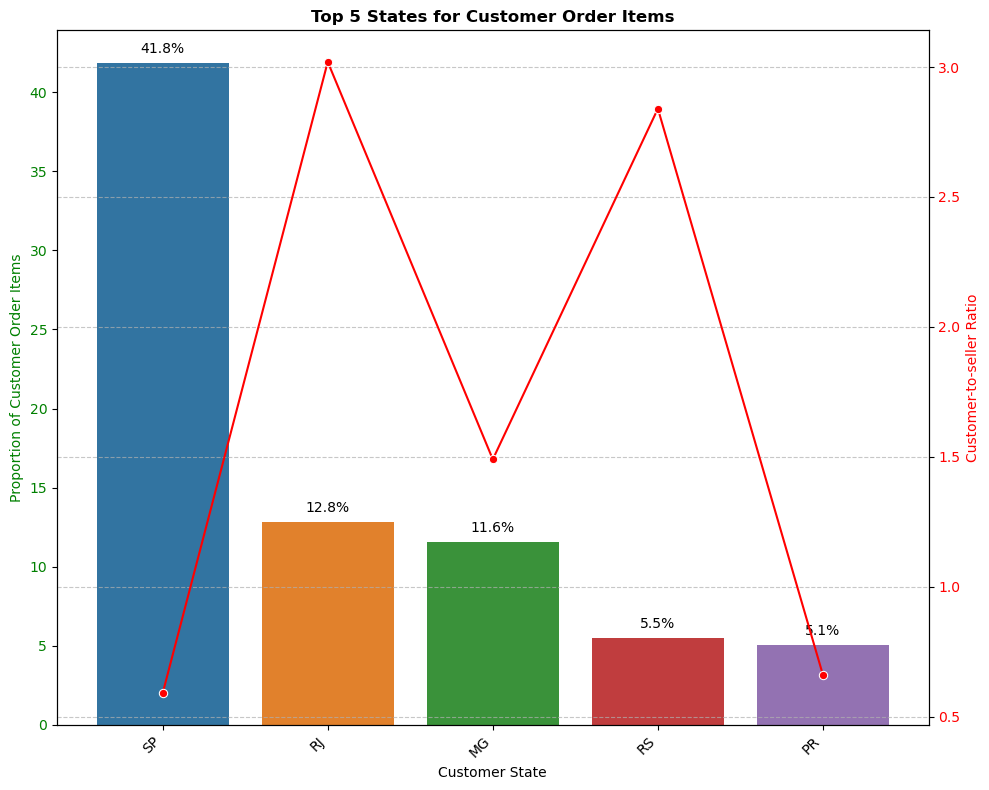

In [22]:
grouped_order_cust_top = grouped_order.nlargest(5, 'pct_items_cust')
grouped_order_cust_top['cust_to_sell'] = round(grouped_order_cust_top['pct_items_cust']/grouped_order_cust_top['pct_items_sell'], 2)
display(grouped_order_cust_top)

# Visualisation ----------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.barplot(x='customer_state', y='pct_items_cust', data=grouped_order_cust_top, ax=ax1)
ax1.set_xlabel('Customer State')
ax1.set_ylabel('Proportion of Customer Order Items', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_title('Top 5 States for Customer Order Items', fontweight='bold')

for bar in ax1.patches:
    ax1.annotate(f'{bar.get_height():.1f}%',
                 (bar.get_x() + bar.get_width() / 2,
                  bar.get_height()), ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points', fontsize=10)

ax2 = ax1.twinx()
sns.lineplot(x='customer_state', y='cust_to_sell', data=grouped_order_cust_top, color='red', marker='o', ax=ax2)
ax2.set_ylabel('Customer-to-seller Ratio', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close()

#### Seller orders

,customer_state,count_items_cust,pct_items_cust,seller_state,count_items_sell,pct_items_sell,cust_to_sell
0,SP,47449.00,41.83,SP,80342.00,70.83,0.59
2,MG,13129.00,11.58,MG,8827.00,7.78,1.49
4,PR,5740.00,5.06,PR,8671.00,7.64,0.66
1,RJ,14579.00,12.85,RJ,4818.00,4.25,3.02
5,SC,4176.00,3.68,SC,4075.00,3.59,1.03


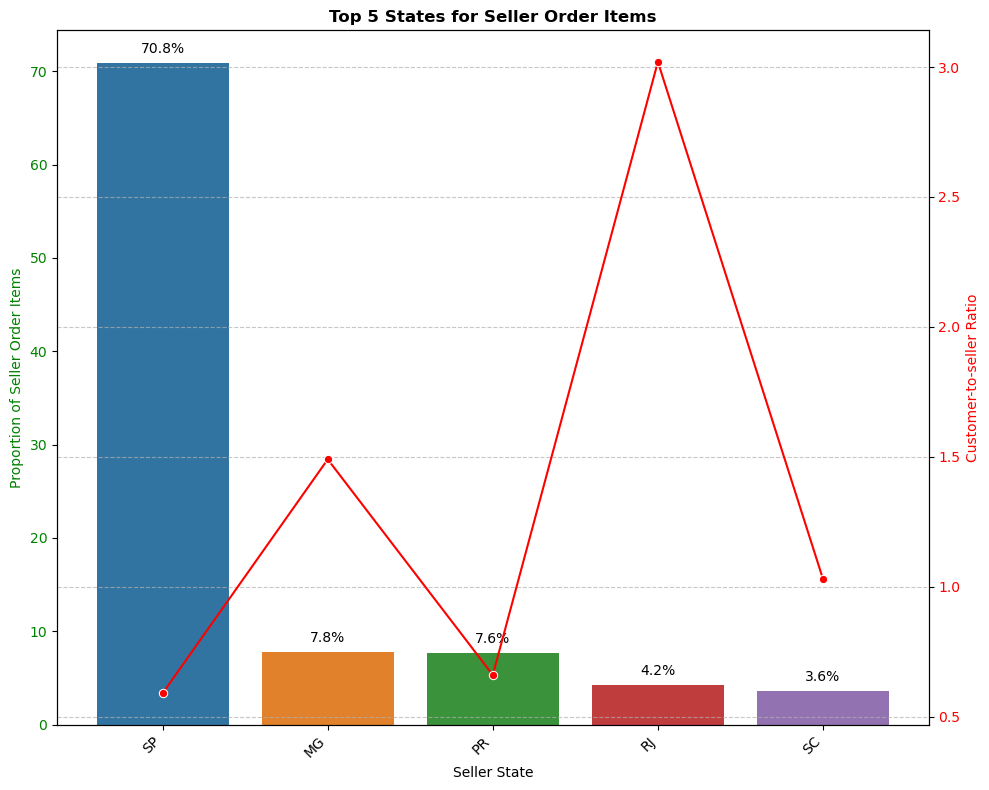

In [23]:
grouped_order_sell_top = grouped_order.nlargest(5, 'pct_items_sell')
grouped_order_sell_top['cust_to_sell'] = round(grouped_order_sell_top['pct_items_cust']/grouped_order_sell_top['pct_items_sell'], 2)
display(grouped_order_sell_top)

# Visualisation ----------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 8))

sns.barplot(x='seller_state', y='pct_items_sell', data=grouped_order_sell_top, ax=ax1)
ax1.set_xlabel('Seller State')
ax1.set_ylabel('Proportion of Seller Order Items', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_title('Top 5 States for Seller Order Items', fontweight='bold')

for bar in ax1.patches:
    ax1.annotate(f'{bar.get_height():.1f}%',
                 (bar.get_x() + bar.get_width() / 2,
                  bar.get_height()), ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points', fontsize=10)

ax2 = ax1.twinx()
sns.lineplot(x='seller_state', y='cust_to_sell', data=grouped_order_sell_top, color='red', marker='o', ax=ax2)
ax2.set_ylabel('Customer-to-seller Ratio', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close()

#### Quantity and Revenue

,product_category_name,unique_orders,pdt_qty,item_revenue,freight_revenue,total_revenue,total_revenue_per_qty
8,bed_bath_table,9417,11115,1036988.68,204693.04,1241681.72,111.71
44,health_beauty,8836,9670,1258681.34,182566.73,1441248.07,149.04
68,sports_leisure,7720,8641,988048.97,168607.51,1156656.48,133.86
40,furniture_decor,6449,8334,729762.49,172749.30,902511.79,108.29
16,computers_accessories,6689,7827,911954.32,147318.08,1059272.40,135.34


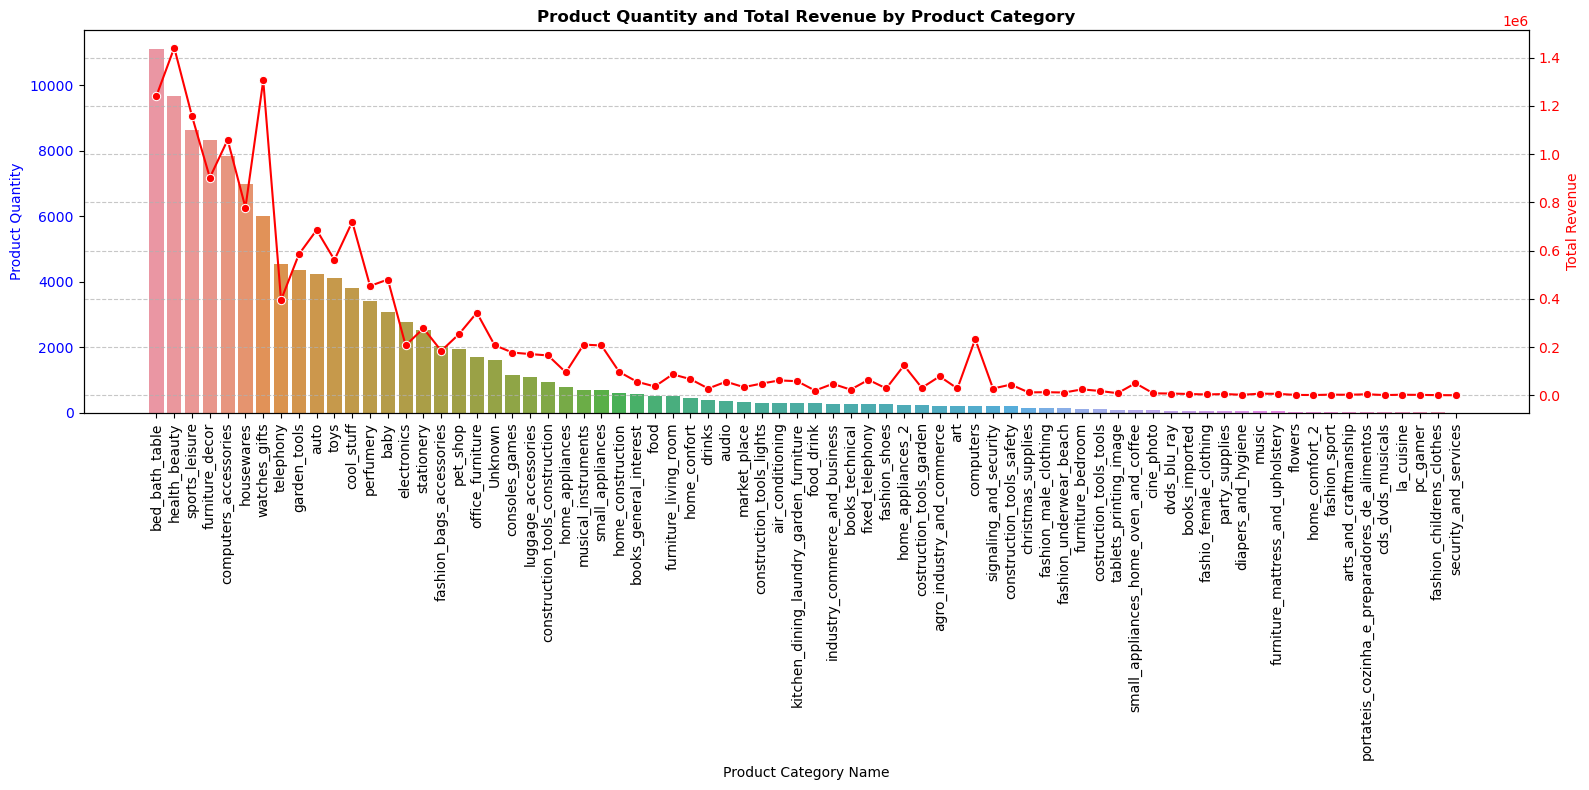

In [24]:
groupby_cols = ['product_category_name']
grouped = all_df.groupby(groupby_cols, dropna=False).agg(
    unique_orders = ('order_id', 'nunique'),
    pdt_qty = ('product_id', 'count'),
    item_revenue = ('price', 'sum'),
    freight_revenue = ('freight_value', 'sum'),
    total_revenue = ('item_revenue', 'sum')
).reset_index().sort_values('pdt_qty', ascending=False)
grouped['total_revenue_per_qty'] = round(grouped['total_revenue'] / grouped['pdt_qty'], 2)
display(grouped.head())

top_categories = grouped.nlargest(5, 'pdt_qty')['product_category_name'].tolist()

# Visualisation ----------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(16, 8))

sns.barplot(x='product_category_name', y='pdt_qty', data=grouped, ax=ax1)
ax1.set_xlabel('Product Category Name')
ax1.set_ylabel('Product Quantity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Product Quantity and Total Revenue by Product Category', fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x='product_category_name', y='total_revenue', data=grouped, ax=ax2, color='red', marker='o')
ax2.set_ylabel('Total Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='center')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close()

#### Seasonality
- Spike in orders in Nov 2017, specifically 2017-11-24 and 2017-11-27 due to Black Friday and Cyber Monday sales

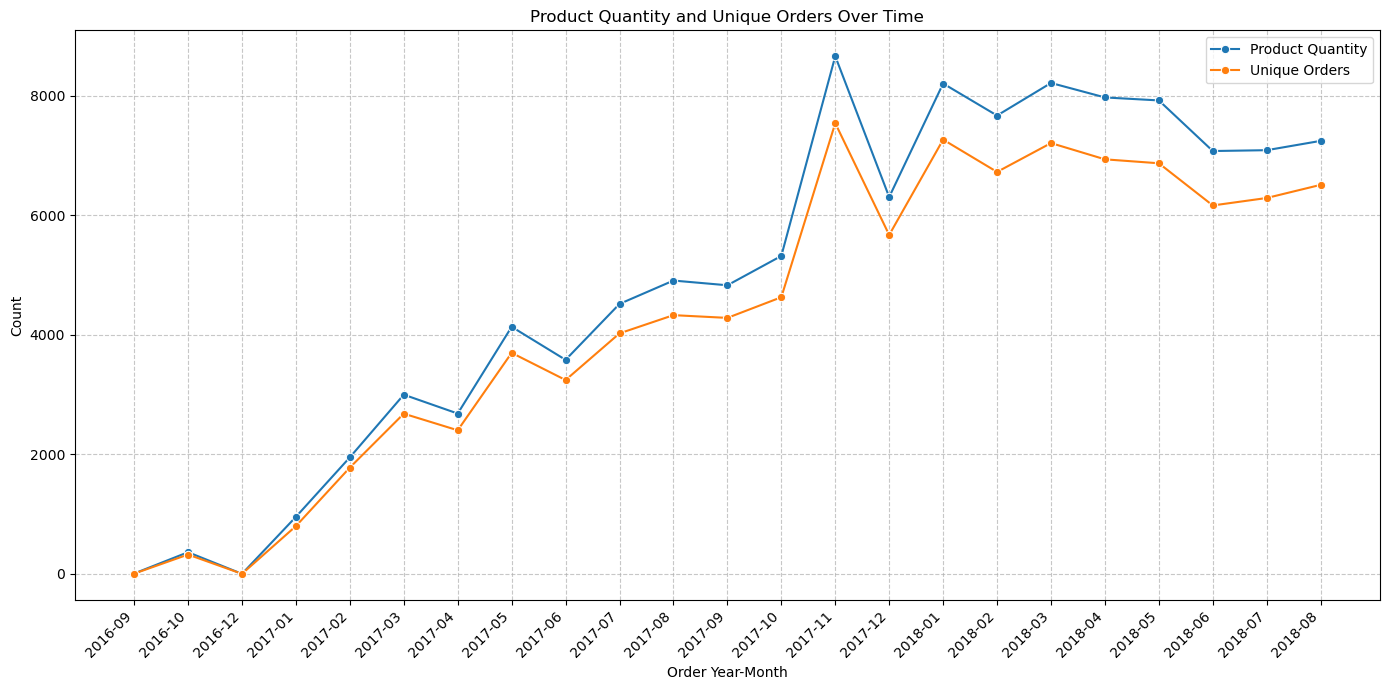

In [25]:
groupby_cols = ['order_yyyymm']
grouped = all_df[all_df['order_yyyymm'] <= '2018-08'].groupby(groupby_cols, dropna=False).agg(
    unique_orders = ('order_id', 'nunique'),
    pdt_qty = ('product_id', 'count')
).reset_index().sort_values(groupby_cols)

plt.figure(figsize=(14, 7))
sns.lineplot(data=grouped, x='order_yyyymm', y='pdt_qty', marker='o', label='Product Quantity')
sns.lineplot(data=grouped, x='order_yyyymm', y='unique_orders', marker='o', label='Unique Orders')
plt.title('Product Quantity and Unique Orders Over Time')
plt.xlabel('Order Year-Month')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

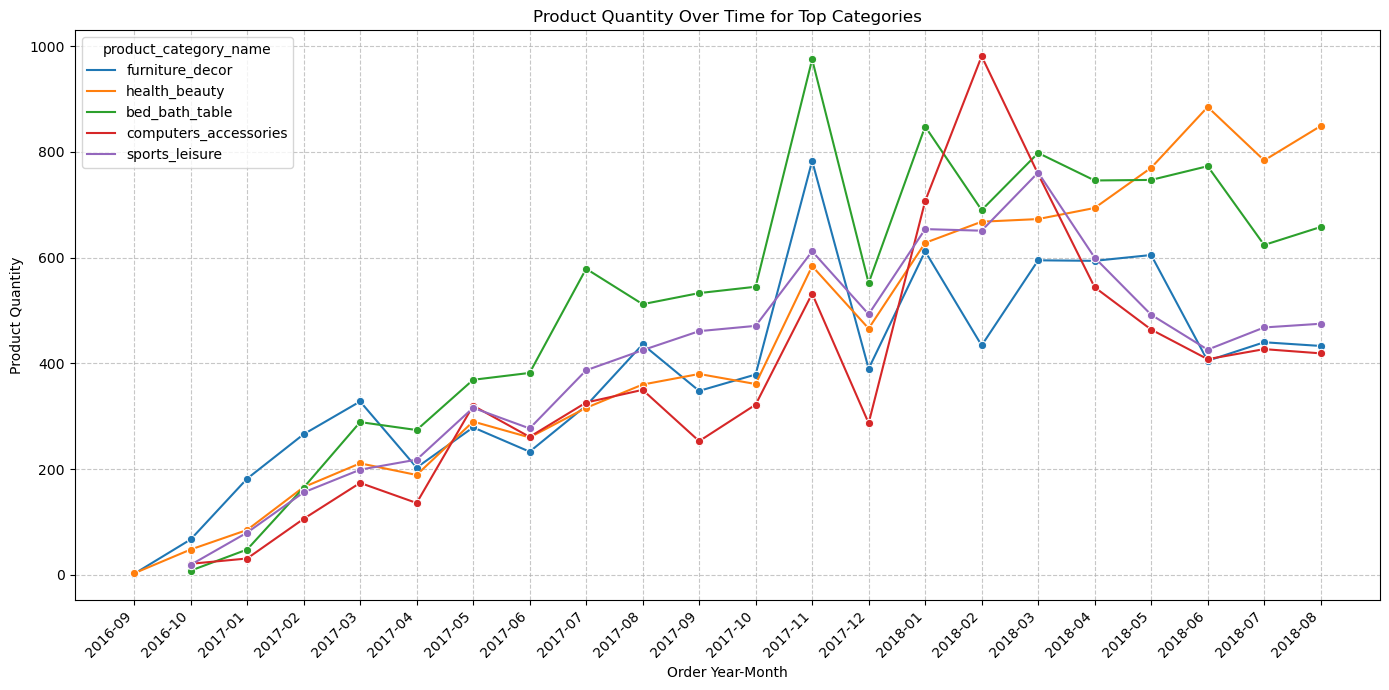

In [26]:
groupby_cols = ['order_yyyymm', 'product_category_name']
grouped = all_df.groupby(groupby_cols, dropna=False).agg(
    pdt_qty = ('product_id', 'count')
).reset_index().sort_values(groupby_cols)

grouped_top_cat = grouped[grouped['product_category_name'].isin(top_categories)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=grouped_top_cat, x='order_yyyymm', y='pdt_qty', hue='product_category_name', marker='o')
plt.title('Product Quantity Over Time for Top Categories')
plt.xlabel('Order Year-Month')
plt.ylabel('Product Quantity')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close()

#### Customer preferences

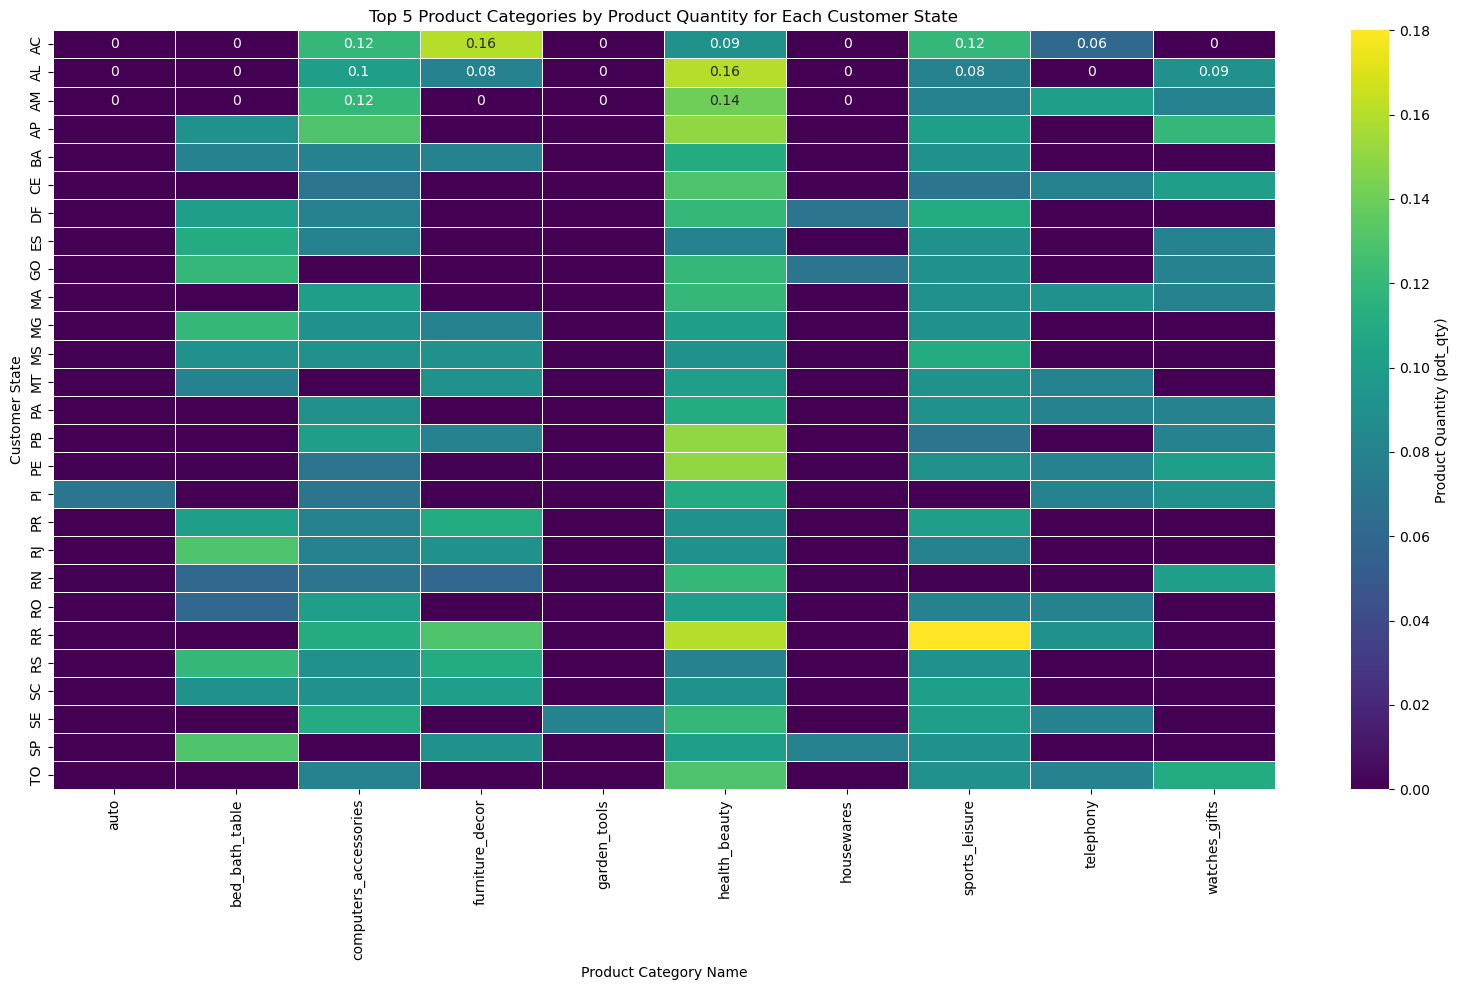

In [52]:
groupby_cols = ['customer_state', 'product_category_name']
pdt_grouped = all_df.groupby(groupby_cols, dropna=False).agg(
    pdt_qty = ('product_id', 'count')
).reset_index().sort_values(groupby_cols)

groupby_cols = ['customer_state']
customers_grouped = customers.groupby(groupby_cols).agg(
    unique_customers = ('customer_unique_id', 'nunique'),
).reset_index().sort_values(by='unique_customers', ascending=False)

pdt_grouped = pdt_grouped.merge(customers_grouped
                                , on='customer_state'
                                , how='left'
                                )
pdt_grouped['pdt_qty_per_customer'] = round(pdt_grouped['pdt_qty'] / pdt_grouped['unique_customers'], 2)
pdt_grouped = pdt_grouped.groupby('customer_state').apply(lambda x: x.nlargest(5, 'pdt_qty')).reset_index(drop=True)
# display(pdt_grouped)

# Visualisation ---------------------------------------------------------------------------------------------------------
heatmap_data = pdt_grouped.pivot_table(index='customer_state'
                                    , columns='product_category_name'
                                    , values='pdt_qty_per_customer', fill_value=0
                                    )

plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='viridis', linewidths=.5, cbar_kws={'label': 'Product Quantity (pdt_qty)'})
plt.title('Top 5 Product Categories by Product Quantity for Each Customer State')
plt.xlabel('Product Category Name')
plt.ylabel('Customer State')
plt.tight_layout()
plt.show()
plt.close()

## Analyse delivery routes

### Get interstate tagging by considering each item's origin state

In [28]:
all_order_items = order_items.merge(sellers[['seller_id', 'seller_state', 'seller_city']]
                                        , on='seller_id'
                                        , how='left'
                                        )
orders_routes = orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']]
                          , on='customer_id'
                          , how='left'
                          )
orders_routes = orders_routes.merge(all_order_items,
                                    on='order_id',
                                    how='left'
                                    )
orders_routes.drop(columns=['product_id', 'shipping_limit_date'], inplace=True)
orders_routes = orders_routes.sort_values(['order_id', 'seller_id'])

orders_routes['item_is_interstate'] = orders_routes['customer_state'] != orders_routes['seller_state']

print(f"Unique orders: {orders_routes['order_id'].nunique()}")
print(f"Shape: {orders_routes.shape}")
orders_routes.tail(5)

Unique orders: 99441
Shape: (113425, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,order_item_id,seller_id,price,freight_value,seller_state,seller_city,item_is_interstate
90607,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,0c9aeda10a71f369396d0c04dce13a64,MA,sao luis,1.00,b8bc237ba3788b23da09c0f1f3a3288c,299.99,43.41,SC,itajai,True
79965,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,0da9fe112eae0c74d3ba1fe16de0988b,PR,curitiba,1.00,f3c38ab652836d21de61fb8314b69182,350.00,36.53,SP,sao paulo,True
60038,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,cd79b407828f02fdbba457111c38e4c4,SP,sao paulo,1.00,c3cfdc648177fdbbbb35635a37472c53,99.90,16.95,PR,curitiba,True
68190,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25,eb803377c9315b564bdedad672039306,SP,vinhedo,1.00,2b3e4a2a3ea8e01938cabda2a3e5cc79,55.99,8.72,SP,sao paulo,False
68036,fffe41c64501cc87c801fd61db3f6244,96d649da0cc4ff33bb408b199d4c7dcf,delivered,2018-06-09 17:00:18,2018-06-09 17:10:13,2018-06-11 14:11:00,2018-06-14 17:56:26,2018-06-28,cd76a00d8e3ca5e6ab9ed9ecb6667ac4,SP,botucatu,1.00,f7ccf836d21b2fb1de37564105216cc1,43.00,12.79,SP,ibitinga,False


In [29]:
groupby_cols = ['order_id', 'order_status', 'customer_state']
orders_routes_states = orders_routes.groupby(groupby_cols).agg(
                                    seller_count=('seller_id', 'nunique'),
                                    seller_state_count=('seller_state', 'nunique'),
                                    interstate_item_count=('item_is_interstate', 'sum'),
                                    item_count=('order_item_id', 'count'),
                                    all_interstate=('item_is_interstate', 'all'),
                                    any_interstate=('item_is_interstate', 'any')
                                ).reset_index()
orders_routes_states['route_type'] = np.select([orders_routes_states['all_interstate'], ~orders_routes_states['any_interstate']],
                                                ['1. All interstate', '2. All same-state'],
                                               default='3. Mixed'
                                               )

print(f"Unique orders: {orders_routes_states['order_id'].nunique()}")
print(f"Shape: {orders_routes_states.shape}")
grouped = orders_routes_states.groupby('route_type').agg(
    order_count = ('order_id', 'nunique'),
    ).reset_index().sort_values('route_type')
grouped['pct'] = round(grouped['order_count']/orders_routes_states['order_id'].nunique()*100, 2)
display(grouped)

Unique orders: 99441
Shape: (99441, 10)


,route_type,order_count,pct
0,1. All interstate,63841,64.20
1,2. All same-state,35353,35.55
2,3. Mixed,247,0.25


In [30]:
delivered_orders = orders_routes_states[orders_routes_states['order_status'] == 'delivered']
print(f"Unique delivered orders: {delivered_orders['order_id'].nunique()}")
print(f"Shape: {delivered_orders.shape}")
# display(delivered_orders.tail())

grouped = delivered_orders.groupby('route_type').agg(
    order_count = ('order_id', 'nunique'),
    ).reset_index().sort_values('route_type')
grouped['pct'] = round(grouped['order_count']/delivered_orders['order_id'].nunique()*100, 2)
display(grouped)

Unique delivered orders: 96478
Shape: (96478, 10)


,route_type,order_count,pct
0,1. All interstate,61651,63.90
1,2. All same-state,34580,35.84
2,3. Mixed,247,0.26


,route_type,customer_state,order_count,pct
0,1. All interstate,MG,9815,10.17
1,1. All interstate,PR,4206,4.36
2,1. All interstate,RJ,11389,11.80
3,1. All interstate,RS,5056,5.24
4,1. All interstate,SP,9667,10.02
5,2. All same-state,MG,1510,1.57
6,2. All same-state,PR,706,0.73
7,2. All same-state,RJ,944,0.98
8,2. All same-state,RS,287,0.30
9,2. All same-state,SP,30651,31.77


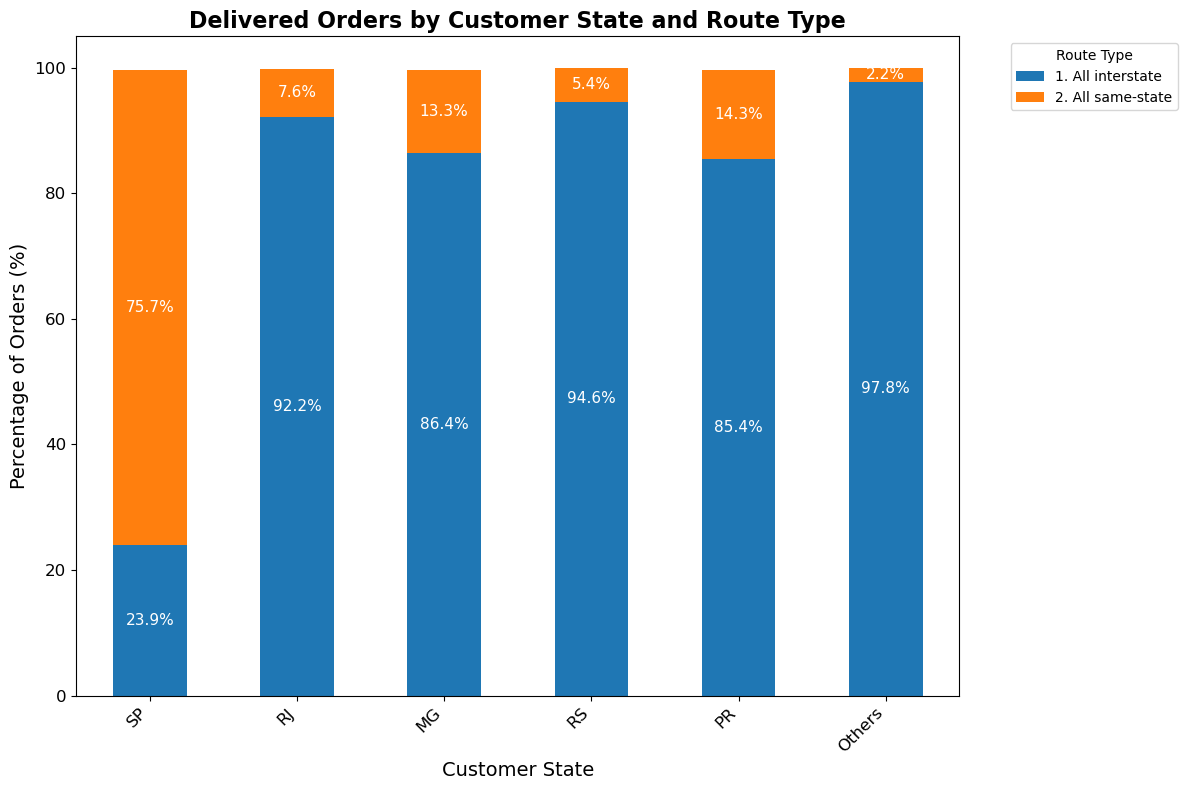

In [31]:
top_cust_states = ['SP', 'RJ', 'MG', 'RS', 'PR']

groupby_cols = ['route_type', 'customer_state']
grouped = delivered_orders[delivered_orders['customer_state'].isin(top_cust_states)].groupby(groupby_cols).agg(
    order_count = ('order_id', 'nunique'),
    ).reset_index().sort_values(groupby_cols)
grouped['pct'] = round(grouped['order_count']/delivered_orders['order_id'].nunique()*100, 2)
display(grouped)

# Visualisation ----------------------------------------------------------------------------
df_plot = delivered_orders.copy()
df_plot['customer_state_grouped'] = df_plot['customer_state'].apply(lambda x: x if x in top_cust_states else 'Others')

grouped_data = df_plot.groupby(['route_type', 'customer_state_grouped']).agg(
    order_count=('order_id', 'nunique')
).reset_index()
total_orders_per_state = grouped_data.groupby('customer_state_grouped')['order_count'].transform('sum')

grouped_data['percentage'] = (grouped_data['order_count'] / total_orders_per_state * 100).round(1)
grouped_data = grouped_data[grouped_data['route_type'] != '3. Mixed']
pivot_df = grouped_data.pivot_table(index='customer_state_grouped', columns='route_type', values='percentage', fill_value=0)

sorted_index = [state for state in top_cust_states if state in pivot_df.index] + ['Others']
sorted_index = [idx for idx in sorted_index if idx in pivot_df.index]
pivot_df = pivot_df.reindex(sorted_index)

pivot_df = pivot_df[['1. All interstate', '2. All same-state']]

fig, ax = plt.subplots(figsize=(12, 8))

pivot_df.plot(kind='bar', stacked=True, ax=ax)

ax.set_title('Delivered Orders by Customer State and Route Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Customer State', fontsize=14)
ax.set_ylabel('Percentage of Orders (%)', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=12)
plt.setp(ax.get_xticklabels(), ha='right')
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Route Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='white')

plt.tight_layout()
plt.show()
plt.close()

### Analyse interstate taggings with delvery times

In [32]:
orders_time = orders.copy()
orders_time['purchase_to_approve_days'] = (orders_time['order_approved_at'] - orders_time['order_purchase_timestamp']).dt.days
orders_time['approve_to_carrier_days'] = (orders_time['order_delivered_carrier_date'] - orders_time['order_approved_at']).dt.days
orders_time['carrier_to_delivered_days'] = (orders_time['order_delivered_customer_date'] - orders_time['order_delivered_carrier_date']).dt.days
orders_time['purchase_to_delivered_days'] = (orders_time['order_delivered_customer_date'] - orders_time['order_purchase_timestamp']).dt.days
orders_time['estimated_delivery_days'] = (orders_time['order_estimated_delivery_date'] - orders_time['order_purchase_timestamp']).dt.days
orders_time['delivery_error_days'] = (orders_time['order_delivered_customer_date'] - orders_time['order_estimated_delivery_date']).dt.days
orders_time['ind_late_delivery'] = (orders_time['order_delivered_customer_date'].dt.normalize() > orders_time['order_estimated_delivery_date']).astype(int)

orders_time = orders_time.merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']]
                          , on='customer_id'
                          , how='left'
                          )
orders_time = orders_time.merge(orders_routes_states[['order_id', 'item_count', 'route_type']], on='order_id', how='left')
delivered_orders = orders_time[orders_time['order_status'] == 'delivered']
print(delivered_orders.shape)
delivered_orders.head(5)

(96478, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_to_approve_days,approve_to_carrier_days,carrier_to_delivered_days,purchase_to_delivered_days,estimated_delivery_days,delivery_error_days,ind_late_delivery,customer_unique_id,customer_state,customer_city,item_count,route_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.00,2.00,6.00,8.00,15,-8.00,0,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,1,2. All same-state
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.00,0.00,12.00,13.00,19,-6.00,0,af07308b275d755c9edb36a90c618231,BA,barreiras,1,1. All interstate
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.00,0.00,9.00,9.00,26,-18.00,0,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,1,1. All interstate
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.00,3.00,9.00,13.00,26,-13.00,0,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,1,1. All interstate
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0.00,0.00,1.00,2.00,12,-10.00,0,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,1,2. All same-state


In [33]:
groupby_cols = ['order_status']
grouped_total = delivered_orders.groupby(groupby_cols, dropna=False).agg(
    order_count = ('order_id', 'nunique'),
    late_orders = ('ind_late_delivery', 'sum'),
    late_rate = ('ind_late_delivery', 'mean'),
    purchase_to_delivered_days_median = ('purchase_to_delivered_days', 'median'),
    estimated_delivery_days_median = ('estimated_delivery_days', 'median'),
    ).reset_index().sort_values(groupby_cols)
grouped_total['late_rate'] = (grouped_total['late_rate'] * 100).round(2)
grouped_total.insert(1, 'route_type', 'Total')

groupby_cols = ['order_status', 'route_type']
grouped = delivered_orders.groupby(groupby_cols, dropna=False).agg(
    order_count = ('order_id', 'nunique'),
    late_orders = ('ind_late_delivery', 'sum'),
    late_rate = ('ind_late_delivery', 'mean'),
    purchase_to_delivered_days_median = ('purchase_to_delivered_days', 'median'),
    estimated_delivery_days_median = ('estimated_delivery_days', 'median'),
    ).reset_index().sort_values(groupby_cols)
grouped['late_rate'] = (grouped['late_rate'] * 100).round(2)

combined_df = pd.concat([grouped, grouped_total], ignore_index=True)
display(combined_df.iloc[:, 1:])

# Interstate orders have higher rate of late deliveries despite having a longer estimated delivery period
# Delivery for interstate orders take twice as long as same-state orders

,route_type,order_count,late_orders,late_rate,purchase_to_delivered_days_median,estimated_delivery_days_median
0,1. All interstate,61651,4970,8.06,12.00,26.00
1,2. All same-state,34580,1563,4.52,6.00,17.00
2,3. Mixed,247,1,0.40,6.00,24.00
3,Total,96478,6534,6.77,10.00,23.00


### Analyse late deliveries by routes

In [34]:
cols_to_select = ['order_id', 'order_status'
                  , 'purchase_to_delivered_days', 'estimated_delivery_days', 'delivery_error_days', 'ind_late_delivery'
                  , 'customer_state', 'route_type'
                  ]
delivered_orders_routes = delivered_orders[cols_to_select]

all_order_items = order_items.copy()
all_order_items = all_order_items.merge(sellers[['seller_id', 'seller_state', 'seller_city']]
                                        , on='seller_id'
                                        , how='left'
                                        )
all_order_items_dedup = all_order_items[['order_id', 'seller_state']].drop_duplicates()

delivered_orders_routes = delivered_orders_routes.merge(all_order_items_dedup[['order_id', 'seller_state']])
delivered_orders_routes = delivered_orders_routes[delivered_orders_routes['route_type'] != '3. Mixed']
print(delivered_orders_routes.shape)

# Duplicated order_id exists because of order_items from different seller_states
delivered_orders_routes[delivered_orders_routes[['order_id']].duplicated(keep=False)].sort_values('order_id')

(96497, 9)


,order_id,order_status,purchase_to_delivered_days,estimated_delivery_days,delivery_error_days,ind_late_delivery,customer_state,route_type,seller_state
73908,002f98c0f7efd42638ed6100ca699b42,delivered,3.00,31,-29.00,0,RS,1. All interstate,SP
73907,002f98c0f7efd42638ed6100ca699b42,delivered,3.00,31,-29.00,0,RS,1. All interstate,MG
24114,00bcee890eba57a9767c7b5ca12d3a1b,delivered,4.00,29,-25.00,0,DF,1. All interstate,SP
24113,00bcee890eba57a9767c7b5ca12d3a1b,delivered,4.00,29,-25.00,0,DF,1. All interstate,PR
79506,01144cadcf64b6427f0a6580a3033220,delivered,11.00,36,-26.00,0,SP,1. All interstate,MT
...,...,...,...,...,...,...,...,...,...
66258,fd0d8a359529c8fc086392d5b309d9ba,delivered,9.00,19,-11.00,0,RS,1. All interstate,RJ
28436,fd863d3852b0a9ebf6b0669312fb71b3,delivered,9.00,35,-27.00,0,RS,1. All interstate,SP
28437,fd863d3852b0a9ebf6b0669312fb71b3,delivered,9.00,35,-27.00,0,RS,1. All interstate,PR
19623,fe755232f249d0844951831268c55593,delivered,10.00,36,-27.00,0,RS,1. All interstate,PR


In [35]:
groupby_cols = ['route_type', 'seller_state', 'customer_state']
grouped = delivered_orders_routes.groupby(groupby_cols, dropna=False).agg(
    order_item_count = ('order_id', 'count'),
    late_orders = ('ind_late_delivery', 'sum'),
    late_rate = ('ind_late_delivery', 'mean'),
).reset_index().sort_values('order_item_count', ascending=False)
grouped['late_rate'] = round(grouped['late_rate'] * 100, 2)
display(grouped.iloc[:10,:])

,route_type,seller_state,customer_state,order_item_count,late_orders,late_rate
411,2. All same-state,SP,SP,30651,1428,4.66
387,1. All interstate,SP,RJ,8172,1152,14.10
379,1. All interstate,SP,MG,7448,392,5.26
391,1. All interstate,SP,RS,3612,238,6.59
386,1. All interstate,SP,PR,3121,138,4.42
266,1. All interstate,PR,SP,2902,90,3.10
162,1. All interstate,MG,SP,2530,91,3.60
392,1. All interstate,SP,SC,2335,222,9.51
373,1. All interstate,SP,BA,2313,297,12.84
401,2. All same-state,MG,MG,1510,38,2.52


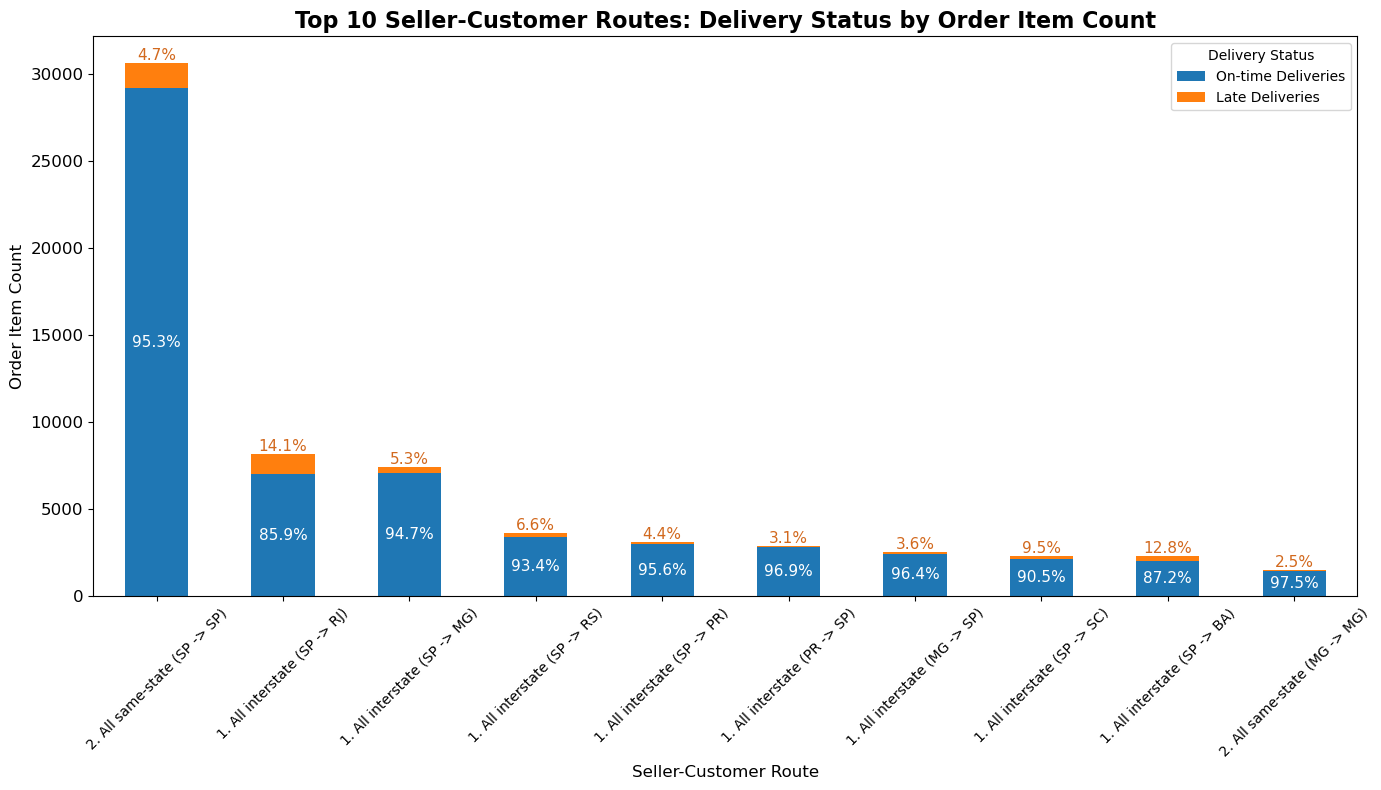

In [36]:
df_plot = grouped.copy()
df_plot['Route'] = df_plot['route_type'] + ' (' + df_plot['seller_state'] + ' -> ' + df_plot['customer_state'] + ')'


df_plot_top10 = df_plot.head(10).copy()
df_plot_top10['On-time Deliveries'] = df_plot_top10['order_item_count'] * (100 - df_plot_top10['late_rate']) / 100
df_plot_top10['Late Deliveries'] = df_plot_top10['order_item_count'] * df_plot_top10['late_rate'] / 100
df_plot_top10.set_index('Route', inplace=True)

df_stacked_plot = df_plot_top10[['On-time Deliveries', 'Late Deliveries']]

fig, ax = plt.subplots(figsize=(14, 8))
df_stacked_plot.plot(kind='bar', stacked=True, ax=ax)

ax.set_title('Top 10 Seller-Customer Routes: Delivery Status by Order Item Count', fontsize=16, fontweight='bold')
ax.set_xlabel('Seller-Customer Route', fontsize=12)
ax.set_ylabel('Order Item Count', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Delivery Status', loc='upper right', fontsize=10)

on_time_container = ax.containers[0]
on_time_labels = []
for j, v in enumerate(on_time_container):
    height = v.get_height()
    total_bar_height = df_plot_top10['order_item_count'].iloc[j]
    if total_bar_height > 0:
        percentage = (height / total_bar_height) * 100
        on_time_labels.append(f'{percentage:.1f}%')
    else:
        on_time_labels.append('')
ax.bar_label(on_time_container, labels=on_time_labels, label_type='center', fontsize=11, color='white')

late_container = ax.containers[1]
late_labels = []
for j, v in enumerate(late_container):
    height = v.get_height()
    total_bar_height = df_plot_top10['order_item_count'].iloc[j]
    if total_bar_height > 0:
        percentage = (height / total_bar_height) * 100
        late_labels.append(f'{percentage:.1f}%')
    else:
        late_labels.append('')
ax.bar_label(late_container, labels=late_labels, label_type='edge', fontsize=11, color='chocolate')

plt.tight_layout()
plt.show()
plt.close()

### Lead time decomposition

In [37]:
orders_time = orders.copy()

orders_time['order_purchase_timestamp'] = orders_time['order_purchase_timestamp'].dt.normalize()
orders_time['order_approved_at'] = orders_time['order_approved_at'].dt.normalize()
orders_time['order_delivered_carrier_date'] = orders_time['order_delivered_carrier_date'].dt.normalize()
orders_time['order_delivered_customer_date'] = orders_time['order_delivered_customer_date'].dt.normalize()
orders_time['order_estimated_delivery_date'] = orders_time['order_estimated_delivery_date'].dt.normalize()

orders_time['purchase_to_approve_days'] = (orders_time['order_approved_at'] - orders_time['order_purchase_timestamp']).dt.days
orders_time['approve_to_carrier_days'] = (orders_time['order_delivered_carrier_date'] - orders_time['order_approved_at']).dt.days
orders_time['carrier_to_delivered_days'] = (orders_time['order_delivered_customer_date'] - orders_time['order_delivered_carrier_date']).dt.days
orders_time['purchase_to_delivered_days'] = (orders_time['order_delivered_customer_date'] - orders_time['order_purchase_timestamp']).dt.days
orders_time['estimated_delivery_days'] = (orders_time['order_estimated_delivery_date'] - orders_time['order_purchase_timestamp']).dt.days
orders_time['delivery_error_days'] = (orders_time['order_delivered_customer_date'] - orders_time['order_estimated_delivery_date']).dt.days

orders_time['ind_late_delivery'] = (orders_time['order_delivered_customer_date'] > orders_time['order_estimated_delivery_date']).astype(int)

orders_time = orders_time.merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']]
                          , on='customer_id'
                          , how='left'
                          )
print("orders_time.shape:", orders_time.shape)
# display(orders_time.head())

orders_time_delivered = orders_time[orders_time['order_status'] == 'delivered'].copy()

orders_time_delivered['purchase_to_approve_days_pct'] = orders_time_delivered['purchase_to_approve_days'] / orders_time_delivered['purchase_to_delivered_days']
orders_time_delivered['approve_to_carrier_days_pct'] = orders_time_delivered['approve_to_carrier_days'] / orders_time_delivered['purchase_to_delivered_days']
orders_time_delivered['carrier_to_delivered_days_pct'] = orders_time_delivered['carrier_to_delivered_days'] / orders_time_delivered['purchase_to_delivered_days']

print("orders_time_delivered.shape:", orders_time_delivered.shape)
orders_time_delivered.head()

orders_time.shape: (99441, 18)
orders_time_delivered.shape: (96478, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_to_approve_days,approve_to_carrier_days,carrier_to_delivered_days,purchase_to_delivered_days,estimated_delivery_days,delivery_error_days,ind_late_delivery,customer_unique_id,customer_state,customer_city,purchase_to_approve_days_pct,approve_to_carrier_days_pct,carrier_to_delivered_days_pct
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02,2017-10-04,2017-10-10,2017-10-18,0.00,2.00,6.00,8.00,16,-8.00,0,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,0.00,0.25,0.75
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-26,2018-07-26,2018-08-07,2018-08-13,2.00,0.00,12.00,14.00,20,-6.00,0,af07308b275d755c9edb36a90c618231,BA,barreiras,0.14,0.00,0.86
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08,2018-08-08,2018-08-17,2018-09-04,0.00,0.00,9.00,9.00,27,-18.00,0,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,0.00,0.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18,2017-11-22,2017-12-02,2017-12-15,0.00,4.00,10.00,14.00,27,-13.00,0,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,0.00,0.29,0.71
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13,2018-02-14,2018-02-16,2018-02-26,0.00,1.00,2.00,3.00,13,-10.00,0,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,0.00,0.33,0.67


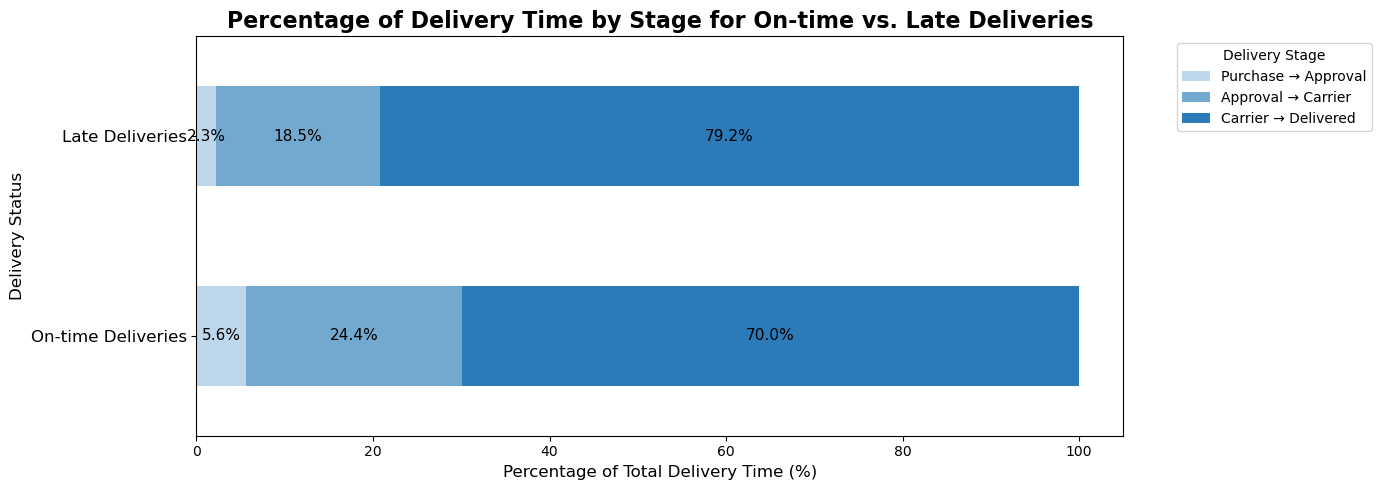

In [38]:
groupby_cols = ['order_status', 'ind_late_delivery']
grouped = orders_time_delivered.groupby(groupby_cols).agg(
    delivered_orders_count = ('order_id', 'nunique'),
    purchase_to_approve_days_pct_mean = ('purchase_to_approve_days_pct', 'mean'),
    approve_to_carrier_days_pct_mean = ('approve_to_carrier_days_pct', 'mean'),
    carrier_to_delivered_days_pct_mean = ('carrier_to_delivered_days_pct', 'mean'),
).reset_index().sort_values(groupby_cols)

# Visualisation --------------------------------------------------------------------------------------------------
df_plot = grouped[['ind_late_delivery', 'purchase_to_approve_days_pct_mean', 'approve_to_carrier_days_pct_mean', 'carrier_to_delivered_days_pct_mean']].copy()

df_plot['purchase_to_approve_days_pct_mean'] = df_plot['purchase_to_approve_days_pct_mean'] * 100
df_plot['approve_to_carrier_days_pct_mean'] = df_plot['approve_to_carrier_days_pct_mean'] * 100
df_plot['carrier_to_delivered_days_pct_mean'] = df_plot['carrier_to_delivered_days_pct_mean'] * 100

df_plot['Delivery Status'] = df_plot['ind_late_delivery'].map({0: 'On-time Deliveries', 1: 'Late Deliveries'})
df_plot.set_index('Delivery Status', inplace=True)

df_plot = df_plot[['purchase_to_approve_days_pct_mean', 'approve_to_carrier_days_pct_mean', 'carrier_to_delivered_days_pct_mean']]
df_plot.rename(columns={
    'purchase_to_approve_days_pct_mean': 'Purchase → Approval',
    'approve_to_carrier_days_pct_mean': 'Approval → Carrier',
    'carrier_to_delivered_days_pct_mean': 'Carrier → Delivered'
}, inplace=True)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#BFD7EA', '#74A9CF', '#2B7BBA']
df_plot.plot(kind='barh', stacked=True, ax=ax, color=colors)

ax.set_title('Percentage of Delivery Time by Stage for On-time vs. Late Deliveries', fontsize=16, fontweight='bold')
ax.set_xlabel('Percentage of Total Delivery Time (%)', fontsize=12)
ax.set_ylabel('Delivery Status', fontsize=12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Delivery Stage', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_width()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()
plt.close()

### Seller-customer distance and delivery performance

This section improves on the same-state/interstate comparison by estimating straight-line distance between seller and customer postcode-prefix coordinates. Because the geolocation table contains multiple readings per postcode prefix, coordinates are first aggregated to their median. For orders involving multiple sellers, the maximum seller-customer distance is used as the order's geographic exposure.

The distance is an approximation rather than actual road distance. Only pre-outcome location information is used.

In [39]:
geo_by_zip = (
    geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(
        latitude=('geolocation_lat', 'median'),
        longitude=('geolocation_lng', 'median')
    )
)

customer_coordinates = (
    customers[['customer_id', 'customer_zip_code_prefix']]
    .merge(
        geo_by_zip.rename(columns={
            'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
            'latitude': 'customer_latitude',
            'longitude': 'customer_longitude'
        }),
        on='customer_zip_code_prefix',
        how='left'
    )
)

seller_coordinates = (
    sellers[['seller_id', 'seller_zip_code_prefix']]
    .merge(
        geo_by_zip.rename(columns={
            'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
            'latitude': 'seller_latitude',
            'longitude': 'seller_longitude'
        }),
        on='seller_zip_code_prefix',
        how='left'
    )
)

# One row per order-seller
distance_order_seller = (
    order_items[['order_id', 'seller_id']]
    .drop_duplicates()
    .merge(seller_coordinates, on='seller_id', how='left')
    .merge(
        orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
    .merge(customer_coordinates, on='customer_id', how='left')
)

def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised great-circle distance in kilometres."""
    earth_radius_km = 6371.0088
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

distance_order_seller['distance_km'] = haversine_km(
    distance_order_seller['seller_latitude'],
    distance_order_seller['seller_longitude'],
    distance_order_seller['customer_latitude'],
    distance_order_seller['customer_longitude']
)

# Use the longest seller-customer leg for multi-seller orders
distance_by_order = (
    distance_order_seller
    .groupby('order_id', as_index=False)
    .agg(
        max_distance_km=('distance_km', 'max'),
        mean_distance_km=('distance_km', 'mean'),
        seller_count=('seller_id', 'nunique')
    )
)

distance_delivery = (
    orders[[
        'order_id', 'order_status', 'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]]
    .merge(distance_by_order, on='order_id', how='left')
)

distance_delivery['delivery_deviation_days'] = (
    distance_delivery['order_delivered_customer_date'].dt.normalize()
    - distance_delivery['order_estimated_delivery_date'].dt.normalize()
).dt.days
distance_delivery['ind_late_delivery'] = (
    distance_delivery['delivery_deviation_days'] > 0
).astype(int)

distance_delivery = distance_delivery[
    distance_delivery['order_status'].eq('delivered')
    & distance_delivery['delivery_deviation_days'].notna()
].copy()

coordinate_coverage = distance_delivery['max_distance_km'].notna().mean()
print(f"Delivered orders with usable distance: {coordinate_coverage:.1%}")
display(distance_delivery[[
    'order_id', 'max_distance_km', 'seller_count',
    'delivery_deviation_days', 'ind_late_delivery'
]].head())

Delivered orders with usable distance: 99.5%


,order_id,max_distance_km,seller_count,delivery_deviation_days,ind_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,18.68,1.00,-8.00,0
1,53cdb2fc8bc7dce0b6741e2150273451,861.04,1.00,-6.00,0
2,47770eb9100c2d0c44946d9cf07ec65d,514.55,1.00,-18.00,0
3,949d5b44dbf5de918fe9c16f97b45f8a,1821.81,1.00,-13.00,0
4,ad21c59c0840e6cb83a9ceb5573f8159,29.59,1.00,-10.00,0


,distance_band_km,delivered_orders,late_rate,late_rate_pct
0,0-100,17795,0.04,4.48
1,101-300,13314,0.05,5.20
2,301-600,31521,0.07,6.75
3,"601-1,000",17972,0.07,7.08
4,"1,001-2,000",9764,0.09,9.46
5,"2,000+",5628,0.12,12.03


,distance_band_km,late_orders,median_days_late
0,0-100,797,4.00
1,101-300,692,6.00
2,301-600,2128,7.00
3,"601-1,000",1272,7.00
4,"1,001-2,000",924,7.00
5,"2,000+",677,8.00


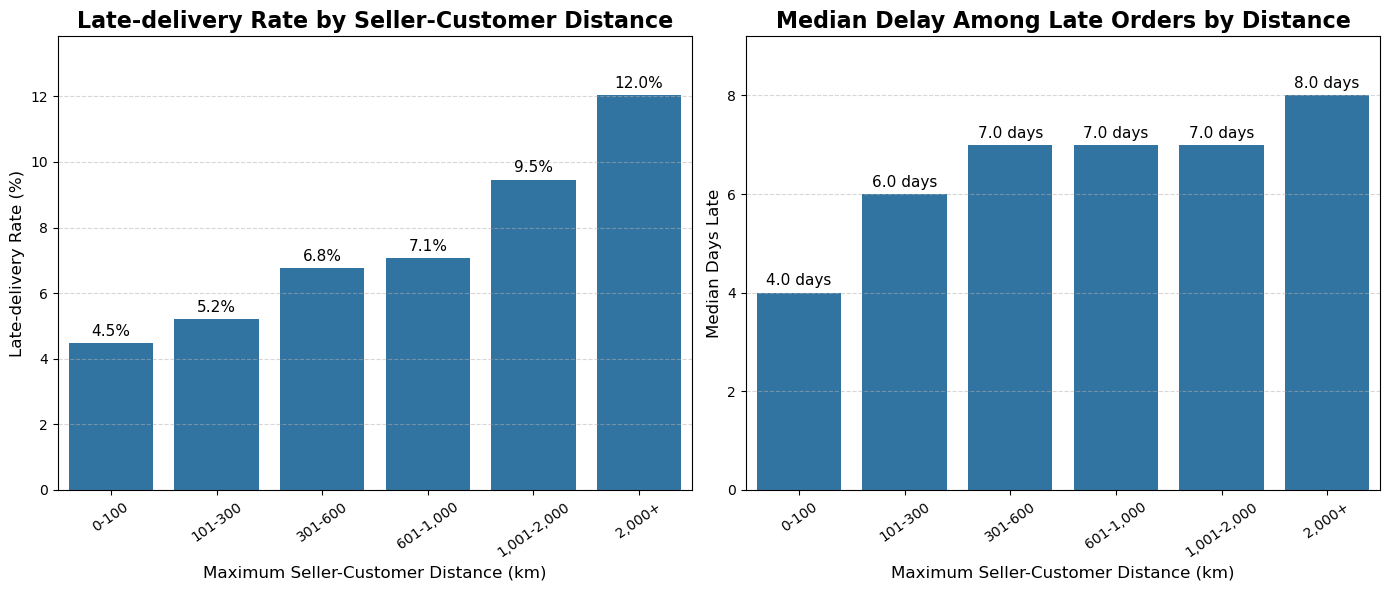

In [40]:
distance_bins = [0, 100, 300, 600, 1000, 2000, np.inf]
distance_labels = ['0-100', '101-300', '301-600', '601-1,000', '1,001-2,000', '2,000+']

distance_delivery['distance_band_km'] = pd.cut(
    distance_delivery['max_distance_km'],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

# Late-delivery likelihood across all delivered orders
distance_summary = (
    distance_delivery
    .groupby('distance_band_km', observed=True)
    .agg(
        delivered_orders=('order_id', 'nunique'),
        late_rate=('ind_late_delivery', 'mean')
    )
    .reset_index()
)
distance_summary['late_rate_pct'] = distance_summary['late_rate'] * 100

# Delay severity among late orders only, matching the Streamlit dashboard
late_distance_summary = (
    distance_delivery[distance_delivery['ind_late_delivery'].eq(1)]
    .groupby('distance_band_km', observed=True)
    .agg(
        late_orders=('order_id', 'nunique'),
        median_days_late=('delivery_deviation_days', 'median')
    )
    .reset_index()
)

display(distance_summary)
display(late_distance_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=distance_summary,
    x='distance_band_km',
    y='late_rate_pct',
    color='tab:blue',
    ax=axes[0]
)
axes[0].set_title('Late-delivery Rate by Seller-Customer Distance', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Maximum Seller-Customer Distance (km)', fontsize=12)
axes[0].set_ylabel('Late-delivery Rate (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=35, labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_ylim(0, distance_summary['late_rate_pct'].max() * 1.15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=11)

sns.barplot(
    data=late_distance_summary,
    x='distance_band_km',
    y='median_days_late',
    color='tab:blue',
    ax=axes[1]
)
axes[1].set_title('Median Delay Among Late Orders by Distance', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Maximum Seller-Customer Distance (km)', fontsize=12)
axes[1].set_ylabel('Median Days Late', fontsize=12)
axes[1].tick_params(axis='x', rotation=35, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, late_distance_summary['median_days_late'].max() * 1.15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f days', padding=3, fontsize=11)

plt.tight_layout()
plt.show()


# Estimated delivery windows

In [41]:
# Using orders_time_delivered from "Lead time decomposition"
cols_to_select = ['order_id', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'ind_late_delivery']
orders_time_delivered_window = orders_time_delivered[cols_to_select].copy()
orders_time_delivered_window['estimated_delivery_days'] = (orders_time_delivered_window['order_estimated_delivery_date'] - orders_time_delivered_window['order_purchase_timestamp']).dt.days

bins = [0, 10, 20, 30, 40, float('inf')]

labels = [
    '01. 0–10',
    '02. 11–20',
    '03. 21–30',
    '04. 31–40',
    '05. 41+'
]

orders_time_delivered_window['estimated_delivery_window'] = pd.cut(
    orders_time_delivered_window['estimated_delivery_days'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(orders_time_delivered_window.shape)

orders_time_delivered_window.head()

groupby_cols = ['estimated_delivery_window']
grouped = orders_time_delivered_window.groupby(groupby_cols).agg(
    delivered_orders_count = ('order_id', 'nunique'),
).reset_index().sort_values(groupby_cols)
display(grouped)

(96478, 7)


,estimated_delivery_window,delivered_orders_count
0,01. 0–10,3945
1,02. 11–20,26721
2,03. 21–30,45940
3,04. 31–40,16016
4,05. 41+,3856


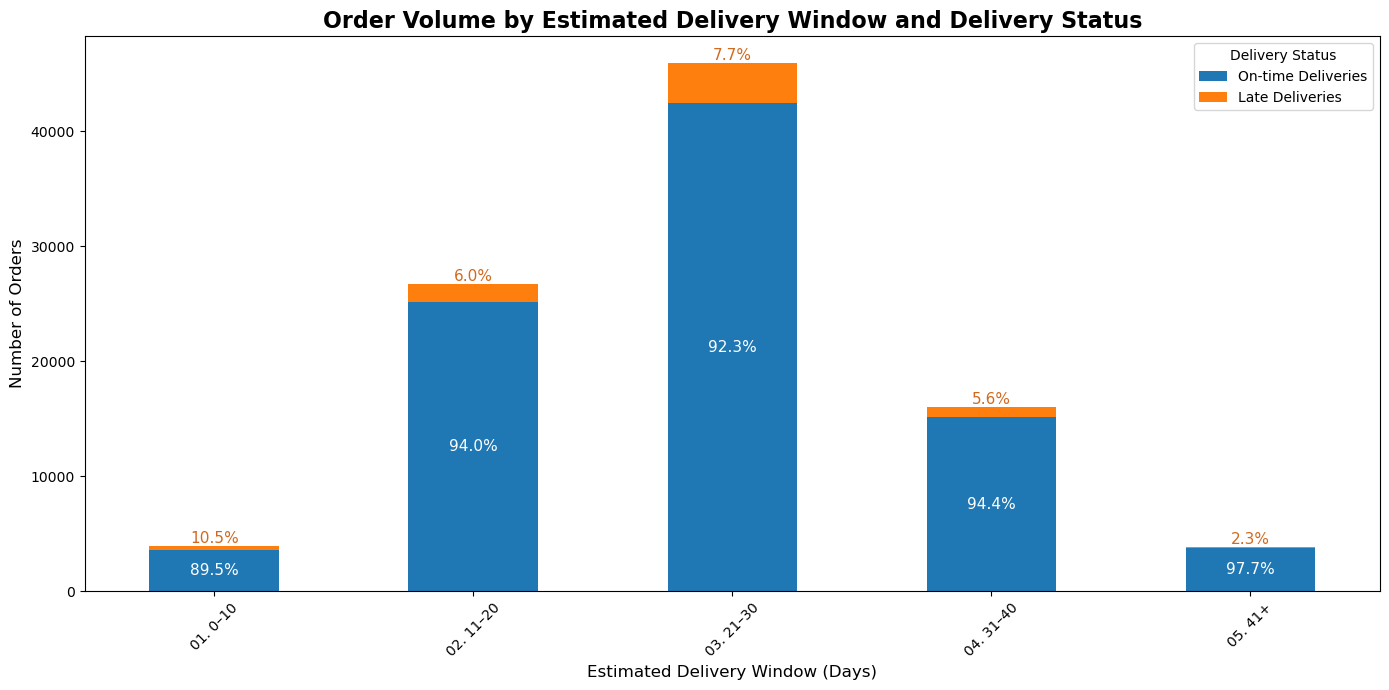

In [42]:
grouped_delivery_window = orders_time_delivered_window.groupby(['estimated_delivery_window', 'ind_late_delivery']).agg(
    order_count=('order_id', 'nunique')
).reset_index()

grouped_delivery_window['total_orders_window'] = grouped_delivery_window.groupby('estimated_delivery_window')['order_count'].transform('sum')
grouped_delivery_window['percentage'] = (grouped_delivery_window['order_count'] / grouped_delivery_window['total_orders_window'] * 100).round(1)
grouped_delivery_window['Delivery Status'] = grouped_delivery_window['ind_late_delivery'].map({0: 'On-time Deliveries', 1: 'Late Deliveries'})

pivot_df_delivery_window = grouped_delivery_window.pivot_table(
    index='estimated_delivery_window',
    columns='Delivery Status',
    values='order_count',
    fill_value=0
)

pivot_df_delivery_window = pivot_df_delivery_window[['On-time Deliveries', 'Late Deliveries']]

colors = {'On-time Deliveries': '#74A9CF', 'Late Deliveries': 'chocolate'}
fig, ax = plt.subplots(figsize=(14, 7))
pivot_df_delivery_window.plot(kind='bar', stacked=True, ax=ax)

ax.set_title('Order Volume by Estimated Delivery Window and Delivery Status', fontsize=16, fontweight='bold')
ax.set_xlabel('Estimated Delivery Window (Days)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(title='Delivery Status', loc='upper right', fontsize=10)

for i, container in enumerate(ax.containers):
    labels = []
    for j, rectangle in enumerate(container):
        total_bar_height = pivot_df_delivery_window.iloc[j].sum()
        height = rectangle.get_height()
        if total_bar_height > 0:
            percentage = (height / total_bar_height) * 100
            if percentage > 0:
                labels.append(f'{percentage:.1f}%')
            else:
                labels.append('')
        else:
            labels.append('')
    if i == 0:
        ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='white')
    elif i == 1:
        ax.bar_label(container, labels=labels, label_type='edge', fontsize=11, color='chocolate')

plt.tight_layout()
plt.show()

# Analysis of continuous variables

In [43]:
# Order items
all_order_items = order_items.copy()
all_order_items = all_order_items.merge(products[['product_id', 'product_category_name', 'product_photos_qty', 'product_weight_g']]
                                    , on='product_id'
                                    , how='left'
                                    )
all_order_items = all_order_items.merge(sellers[['seller_id', 'seller_state', 'seller_city']]
                                        , on='seller_id'
                                        , how='left'
                                        )
all_order_items['item_revenue'] = all_order_items['price'] + all_order_items['freight_value']
all_order_items = all_order_items.sort_values(['order_id', 'order_item_id'])

groupby_cols = ['order_id']
all_order_items_agg = all_order_items.groupby(groupby_cols).agg(
    price = ('price', 'sum'),
    freight_value = ('freight_value', 'sum'),
    item_revenue = ('item_revenue', 'sum'),
    product_weight_g = ('product_weight_g', 'sum'),
    pdt_qty = ('order_item_id', 'nunique')
).reset_index().sort_values(groupby_cols)

# Orders
all_orders = orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']]
                          , on='customer_id'
                          , how='left'
                          )
all_orders['order_date'] = all_orders['order_purchase_timestamp'].dt.normalize()
all_orders['order_yyyymm'] = all_orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
all_orders['order_delivered_carrier_date'] = all_orders['order_delivered_carrier_date'].dt.normalize()
all_orders['order_delivered_customer_date'] = all_orders['order_delivered_customer_date'].dt.normalize()
all_orders['order_estimated_delivery_date'] = all_orders['order_estimated_delivery_date'].dt.normalize()
all_orders['delivery_error_days'] = (all_orders['order_delivered_customer_date'] - all_orders['order_estimated_delivery_date']).dt.days
all_orders['ind_late_delivery'] = (all_orders['order_delivered_customer_date'] > all_orders['order_estimated_delivery_date']).astype(int)
all_orders.drop(columns=['order_purchase_timestamp', 'order_approved_at'], inplace=True)

reviews_agg = reviews.groupby('order_id').agg(
    review_score = ('review_score', 'min')
)
cols_to_select = ['order_id', 'order_yyyymm', 'order_status', 'ind_late_delivery', 'delivery_error_days'
                  , 'price', 'freight_value', 'item_revenue', 'product_weight_g', 'pdt_qty'
                  , 'review_score'
                  ]
delivered_orders = all_orders[all_orders['order_status'] == 'delivered'].merge(all_order_items_agg, on='order_id', how='left')
delivered_orders = delivered_orders.merge(reviews_agg, on='order_id', how='left')
delivered_orders = delivered_orders[cols_to_select].sort_values('order_id')
print(f"Shape: {delivered_orders.shape}")
# display(delivered_orders.head())

# Show correlation matrix
continuous_cols = ['delivery_error_days', 'review_score', 'item_revenue', 'product_weight_g', 'pdt_qty']
corr_matrix = delivered_orders[continuous_cols].corr(method='pearson').round(2)

display(corr_matrix.style
        .format('{:.2f}')
        .set_caption('Pearson Correlation Matrix of Continuous Variables'))

Shape: (96478, 11)


,delivery_error_days,review_score,item_revenue,product_weight_g,pdt_qty
delivery_error_days,1.00,-0.27,-0.02,0.00,-0.03
review_score,-0.27,1.00,-0.04,-0.06,-0.12
item_revenue,-0.02,-0.04,1.00,0.40,0.19
product_weight_g,0.00,-0.06,0.40,1.00,0.23
pdt_qty,-0.03,-0.12,0.19,0.23,1.00


# Analysis of review scores

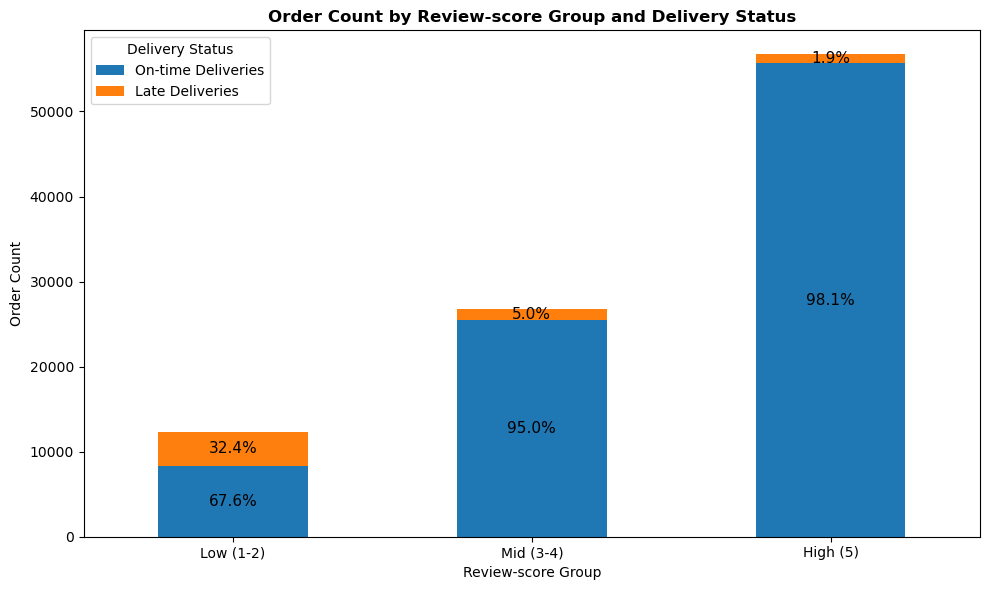

In [53]:
review_delivery = delivered_orders.dropna(subset=['review_score']).copy()
review_delivery['review_score_group'] = pd.cut(
    review_delivery['review_score'],
    bins=[0, 2, 4, 5],
    labels=['Low (1-2)', 'Mid (3-4)', 'High (5)'],
    include_lowest=True
)
review_delivery['delivery_status'] = review_delivery['ind_late_delivery'].map({
    0: 'On-time Deliveries',
    1: 'Late Deliveries'
})

review_delivery_counts = (
    review_delivery.groupby(
        ['review_score_group', 'delivery_status'],
        observed=True
    )
    .agg(order_count=('order_id', 'nunique'))
    .reset_index()
)

review_delivery_counts['percentage'] = (
    review_delivery_counts['order_count']
    / review_delivery_counts.groupby('review_score_group', observed=True)['order_count'].transform('sum')
    * 100
)

review_order = ['Low (1-2)', 'Mid (3-4)', 'High (5)']
hue_order = ['On-time Deliveries', 'Late Deliveries']

count_pivot = (
    review_delivery_counts.pivot(
        index='review_score_group',
        columns='delivery_status',
        values='order_count'
    )
    .reindex(index=review_order, columns=hue_order)
    .fillna(0)
)
percentage_pivot = (
    review_delivery_counts.pivot(
        index='review_score_group',
        columns='delivery_status',
        values='percentage'
    )
    .reindex(index=review_order, columns=hue_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
count_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

for container, delivery_status in zip(ax.containers, hue_order):
    labels = percentage_pivot[delivery_status].map(
        lambda value: f'{value:.1f}%' if value > 0 else ''
    )
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11)

ax.set_title('Order Count by Review-score Group and Delivery Status', fontweight='bold')
ax.set_xlabel('Review-score Group')
ax.set_ylabel('Order Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

# Monthly late orders

Average monthly late delivery rate: 5.886661224535986
Median monthly late delivery rate: 4.443433043737173


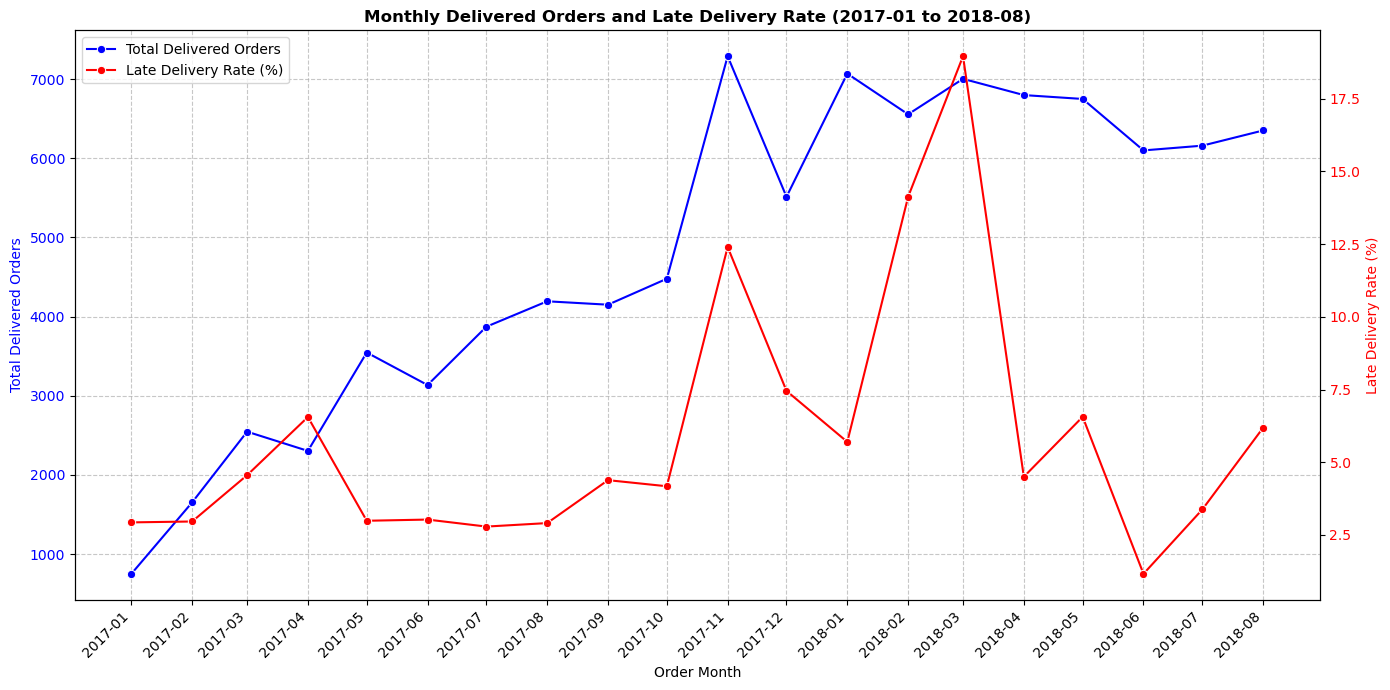

In [44]:
groupby_cols = ['order_yyyymm']
grouped_month = delivered_orders.groupby(groupby_cols).agg(
    delivered_orders_count = ('order_id', 'nunique'),
    late_rate = ('ind_late_delivery', 'mean'),
).reset_index().sort_values(groupby_cols)
grouped_month['late_rate'] = grouped_month['late_rate'] * 100
grouped_month = grouped_month[(grouped_month['order_yyyymm'] >= '2017-01') & (grouped_month['order_yyyymm'] <= '2018-08')]
print(f"Average monthly late delivery rate: {grouped_month['late_rate'].mean()}")
print(f"Median monthly late delivery rate: {grouped_month['late_rate'].median()}")
# display(grouped_month)

# Plot line chart
plot_month = grouped_month.copy()
plot_month['order_yyyymm'] = pd.to_datetime(plot_month['order_yyyymm'], format='%Y-%m')
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(x='order_yyyymm', y='delivered_orders_count', data=plot_month, marker='o', ax=ax1, color='blue', label='Total Delivered Orders')
ax1.set_xlabel('Order Month')
ax1.set_ylabel('Total Delivered Orders', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(x='order_yyyymm', y='late_rate', data=plot_month, marker='o', ax=ax2, color='red', label='Late Delivery Rate (%)')
ax2.set_ylabel('Late Delivery Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Monthly Delivered Orders and Late Delivery Rate (2017-01 to 2018-08)', fontweight='bold')
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45, ha='right')
ax1.grid(True, linestyle='--', alpha=0.7)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()
plt.close()

# Customer Repeat Rate

In [45]:
orders_customers = orders.merge(customers[['customer_id', 'customer_unique_id']]
                          , on='customer_id'
                          , how='left'
                          )
orders_customers = orders_customers[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]
orders_customers['order_month'] = orders_customers['order_purchase_timestamp'].dt.to_period('M')
orders_customers.drop(columns=['order_purchase_timestamp'], inplace=True)
display(orders_customers.head())

groupby_cols = ['customer_unique_id', 'order_month']
orders_customers_month = orders_customers.groupby(groupby_cols).agg(
    order_count = ('order_id', 'nunique')
).reset_index()
samples = ['00172711b30d52eea8b313a7f2cced02',
           '004288347e5e88a27ded2bb23747066c',
           '00a39521eb40f7012db50455bf083460',
           'f0e310a6839dce9de1638e0fe5ab282a'
           ]
display(orders_customers_month[orders_customers_month['customer_unique_id'].isin(samples)])

orders_customers_month_2 = orders_customers_month.copy()
orders_customers_month_2 = orders_customers_month_2.rename(columns={'order_month': 'order_month_2',
                                                                    'order_count': 'order_count_2'})


orders_customers_merged = orders_customers_month.merge(
    orders_customers_month_2,
    on='customer_unique_id',
    how='left'
)
cond = (
    (orders_customers_merged['order_month_2'] >= orders_customers_merged['order_month'] + 1) &
    (orders_customers_merged['order_month_2'] <= orders_customers_merged['order_month'] + 3)
)
orders_customers_n3m = orders_customers_merged[cond].reset_index()
display(orders_customers_n3m[orders_customers_n3m['customer_unique_id'].isin(samples)])

groupby_cols = ['customer_unique_id', 'order_month']
orders_customers_n3m_agg = orders_customers_n3m.groupby(groupby_cols).agg(
    order_count_n3m = ('order_count_2', 'sum')
).reset_index()
print(f"Shape: {orders_customers_n3m_agg.shape}, customers: {orders_customers_n3m_agg['customer_unique_id'].nunique()}")
display(orders_customers_n3m_agg[orders_customers_n3m_agg['customer_unique_id'].isin(samples)])

,customer_unique_id,order_id,order_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02


,customer_unique_id,order_month,order_count
33,00172711b30d52eea8b313a7f2cced02,2018-07,1
34,00172711b30d52eea8b313a7f2cced02,2018-08,1
107,004288347e5e88a27ded2bb23747066c,2017-07,1
108,004288347e5e88a27ded2bb23747066c,2018-01,1
253,00a39521eb40f7012db50455bf083460,2018-05,1
254,00a39521eb40f7012db50455bf083460,2018-06,1
92307,f0e310a6839dce9de1638e0fe5ab282a,2017-05,1
92308,f0e310a6839dce9de1638e0fe5ab282a,2017-08,1
92309,f0e310a6839dce9de1638e0fe5ab282a,2017-09,1
92310,f0e310a6839dce9de1638e0fe5ab282a,2017-10,1


,index,customer_unique_id,order_month,order_count,order_month_2,order_count_2
0,34,00172711b30d52eea8b313a7f2cced02,2018-07,1,2018-08,1
2,262,00a39521eb40f7012db50455bf083460,2018-05,1,2018-06,1
1019,96430,f0e310a6839dce9de1638e0fe5ab282a,2017-05,1,2017-08,1
1020,96437,f0e310a6839dce9de1638e0fe5ab282a,2017-08,1,2017-09,1
1021,96438,f0e310a6839dce9de1638e0fe5ab282a,2017-08,1,2017-10,1
1022,96444,f0e310a6839dce9de1638e0fe5ab282a,2017-09,1,2017-10,1
1023,96458,f0e310a6839dce9de1638e0fe5ab282a,2018-02,1,2018-04,1


Shape: (1023, 3), customers: 956


,customer_unique_id,order_month,order_count_n3m
0,00172711b30d52eea8b313a7f2cced02,2018-07,1
2,00a39521eb40f7012db50455bf083460,2018-05,1
975,f0e310a6839dce9de1638e0fe5ab282a,2017-05,1
976,f0e310a6839dce9de1638e0fe5ab282a,2017-08,2
977,f0e310a6839dce9de1638e0fe5ab282a,2017-09,1
978,f0e310a6839dce9de1638e0fe5ab282a,2018-02,1


In [46]:
order_customers_monthly = orders_customers_month.merge(orders_customers_n3m_agg,
                                                       on=['customer_unique_id', 'order_month'],
                                                       how='left'
                                                       )
order_customers_monthly['order_count_n3m'] = order_customers_monthly['order_count_n3m'].fillna(0)
order_customers_monthly['ind_repeat_n3m'] = (order_customers_monthly['order_count_n3m'] > 0).astype(int)
display(order_customers_monthly[order_customers_monthly['customer_unique_id'].isin(samples)])

,customer_unique_id,order_month,order_count,order_count_n3m,ind_repeat_n3m
33,00172711b30d52eea8b313a7f2cced02,2018-07,1,1.00,1
34,00172711b30d52eea8b313a7f2cced02,2018-08,1,0.00,0
107,004288347e5e88a27ded2bb23747066c,2017-07,1,0.00,0
108,004288347e5e88a27ded2bb23747066c,2018-01,1,0.00,0
253,00a39521eb40f7012db50455bf083460,2018-05,1,1.00,1
254,00a39521eb40f7012db50455bf083460,2018-06,1,0.00,0
92307,f0e310a6839dce9de1638e0fe5ab282a,2017-05,1,1.00,1
92308,f0e310a6839dce9de1638e0fe5ab282a,2017-08,1,2.00,1
92309,f0e310a6839dce9de1638e0fe5ab282a,2017-09,1,1.00,1
92310,f0e310a6839dce9de1638e0fe5ab282a,2017-10,1,0.00,0


Average monthly repeat rate: 1.1335294117647057
Median monthly repeat rate: 1.13


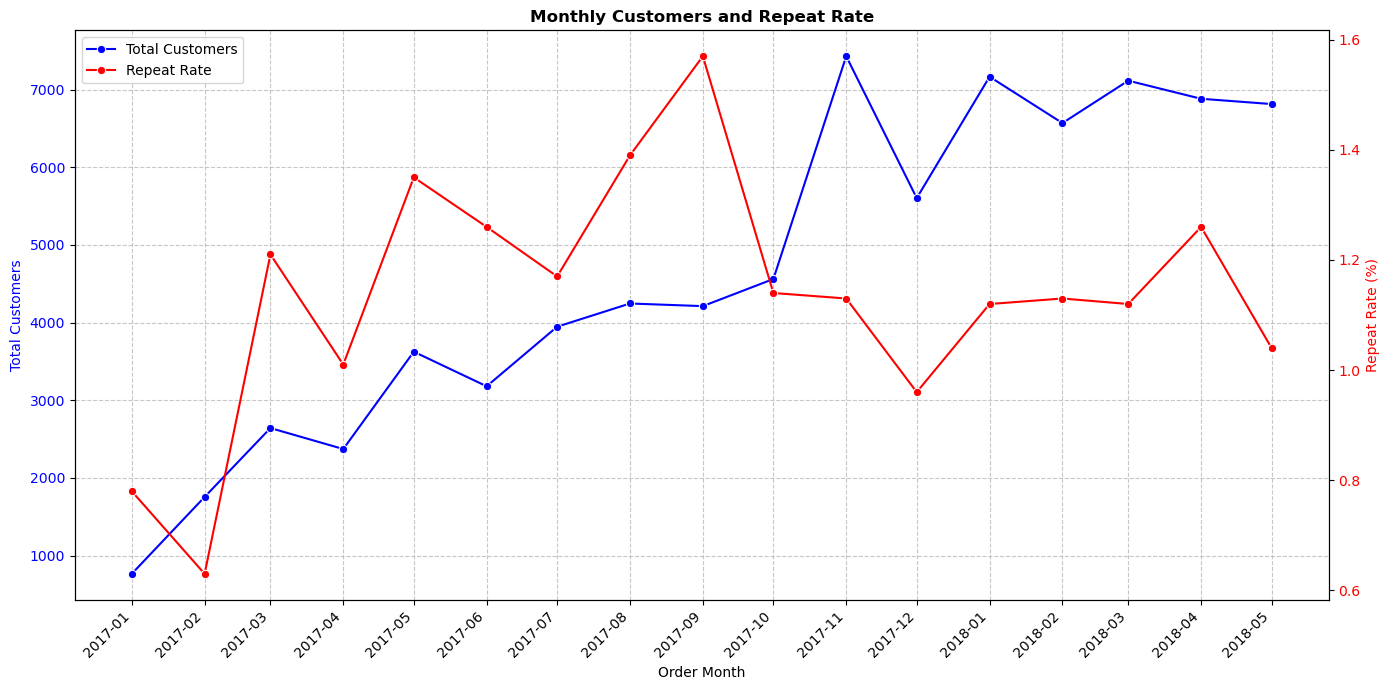

In [47]:
groupby_cols = ['order_month']
grouped = order_customers_monthly.groupby(groupby_cols).agg(
    customers = ('customer_unique_id', 'nunique'),
    repeat_customers = ('ind_repeat_n3m', 'sum'),
    repeat_rate = ('ind_repeat_n3m', 'mean'),
).reset_index().sort_values(groupby_cols)
grouped['repeat_rate'] = (grouped['repeat_rate'] * 100).round(2)
# display(grouped)

filtered_grouped = grouped[(grouped['order_month'] >= '2017-01') & (grouped['order_month'] <= '2018-05')].copy()
filtered_grouped['order_month'] = filtered_grouped['order_month'].dt.to_timestamp()
print(f"Average monthly repeat rate: {filtered_grouped['repeat_rate'].mean()}")
print(f"Median monthly repeat rate: {filtered_grouped['repeat_rate'].median()}")

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(x='order_month', y='customers', data=filtered_grouped, marker='o', ax=ax1, color='blue', label='Total Customers')
ax1.set_xlabel('Order Month')
ax1.set_ylabel('Total Customers', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(x='order_month', y='repeat_rate', data=filtered_grouped, marker='o', ax=ax2, color='red', label='Repeat Rate')
ax2.set_ylabel('Repeat Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Monthly Customers and Repeat Rate', fontweight='bold')
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45, ha='right')
ax1.grid(True, linestyle='--', alpha=0.7)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()